# IFC → Scene Graph → JaxFEM

**Pipeline:**
```
IFC-Datei (IfcOpenShell)
   └─ Bauteil-Parsing (IfcWall, IfcColumn, IfcSlab, ...)
       └─ IFC-Relationship-Analyse
           ├─ IfcRelAggregates          → contains / part_of
           ├─ IfcRelContainedInSpatial  → hosted_in
           ├─ IfcRelAssociatesMaterial  → Material-Mapping
           └─ BBox-Spatial-Analyse      → above / adjacent / near
               └─ NetworkX DiGraph (Scene Graph)
                   ├─ Semantisches Clustering (DBSCAN pro Label)
                   ├─ Feature-Extraktion (Volumen, Höhe, Kompaktheit)
                   ├─ Graphanalyse → Randbedingungen + Lastflächen
                   └─ GMSH Tet4-Netz → JaxFEM Solver
                       └─ Ergebnisse → Scene Graph → LLM-Prompt
```

**Einheiten:** kN, m  
**Referenzen:**
- Poux & Lehtola (2025) — *3D Scene Graphs for Spatial AI + LLMs*
- IFC_FEM_3D.ipynb — BBox-Netz + JaxFEM 3D
- SceneGraph_FEM.ipynb — Synthetischer Scene-Graph-Workflow

## 0 — Importe & Fallbacks

In [38]:
import numpy as onp
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import json
import pathlib
from typing import Dict, List, Tuple, Optional
from scipy.spatial import cKDTree, ConvexHull
from collections import deque

import ifcopenshell
import ifcopenshell.api
import ifcopenshell.geom
import ifcopenshell.util.element
import gmsh
import meshio
import pyvista as pv

from jax_fem.generate_mesh import Mesh
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol

# ── NetworkX Fallback ────────────────────────────────────────────────
try:
    import networkx as nx
except ModuleNotFoundError:
    class _NodeView:
        def __init__(self, g): self._g = g
        def __iter__(self): return iter(self._g._nodes)
        def __len__(self): return len(self._g._nodes)
        def __getitem__(self, n): return self._g._nodes[n]
        def __call__(self, data=False):
            return list(self._g._nodes.items()) if data else list(self._g._nodes.keys())

    class _EdgeView:
        def __init__(self, g): self._g = g
        def __iter__(self): return iter(self._g._edges)
        def __len__(self): return len(self._g._edges)
        def __getitem__(self, e): return self._g._edges[e]
        def __call__(self, data=False):
            return [(u,v,d) for (u,v),d in self._g._edges.items()] if data else list(self._g._edges.keys())

    class _DiGraph:
        def __init__(self):
            self._nodes, self._edges = {}, {}
            self.nodes = _NodeView(self)
            self.edges = _EdgeView(self)
        def add_node(self, n, **a): self._nodes.setdefault(n, {}).update(a)
        def add_edge(self, u, v, **a):
            self._nodes.setdefault(u, {}); self._nodes.setdefault(v, {})
            self._edges[(u, v)] = dict(a)
        def number_of_nodes(self): return len(self._nodes)
        def number_of_edges(self): return len(self._edges)
        def in_edges(self, n):  return [(u,v) for (u,v) in self._edges if v == n]
        def out_edges(self, n): return [(u,v) for (u,v) in self._edges if u == n]
        def degree(self): return [(n, sum(1 for e in self._edges if n in e)) for n in self._nodes]
        def predecessors(self, n): return [u for (u,v) in self._edges if v == n]
        def successors(self, n): return [v for (u,v) in self._edges if u == n]

    def _weak_cc(G):
        seen, comps = set(), 0
        adj = {n: set() for n in G._nodes}
        for u,v in G._edges: adj[u].add(v); adj[v].add(u)
        for s in G._nodes:
            if s in seen: continue
            comps += 1; stack = [s]; seen.add(s)
            while stack:
                n = stack.pop()
                for nb in adj[n]:
                    if nb not in seen: seen.add(nb); stack.append(nb)
        return comps

    def _spring(G, seed=None):
        ns = list(G._nodes)
        if not ns: return {}
        a = onp.linspace(0, 2*onp.pi, len(ns), endpoint=False)
        return {n: (float(onp.cos(x)), float(onp.sin(x))) for n,x in zip(ns,a)}

    def _draw(G, pos, ax=None, node_color=None, edge_color=None,
              node_size=800, font_size=8, arrows=True, arrowsize=20, width=2, **kw):
        ax = ax or plt.gca()
        ns = list(G.nodes); nc = node_color or ['#aaa']*len(ns)
        xy = onp.array([pos[n] for n in ns], dtype=float)
        ax.scatter(xy[:,0], xy[:,1], s=node_size, c=nc, zorder=3, edgecolors='k', linewidths=.5)
        for n,(x,y) in zip(ns,xy): ax.text(x,y,str(n),ha='center',va='center',fontsize=font_size,zorder=4)
        es = list(G.edges); ec = edge_color or ['#888']*len(es)
        for (u,v),c in zip(es,ec):
            x1,y1=pos[u]; x2,y2=pos[v]
            if arrows: ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                arrowprops=dict(arrowstyle='-|>',color=c,lw=width,mutation_scale=arrowsize),zorder=2)
            else: ax.plot([x1,x2],[y1,y2],color=c,lw=width,zorder=2)

    def _elabels(G, pos, edge_labels, font_size=7, ax=None, **kw):
        ax = ax or plt.gca()
        for (u,v),lbl in edge_labels.items():
            x=.5*(pos[u][0]+pos[v][0]); y=.5*(pos[u][1]+pos[v][1])
            ax.text(x,y,str(lbl),fontsize=font_size,ha='center',va='center',
                    bbox=dict(facecolor='white',alpha=.7,edgecolor='none'))

    class _NX:
        __version__ = 'fallback'
        DiGraph = _DiGraph
        number_weakly_connected_components = staticmethod(_weak_cc)
        spring_layout = staticmethod(_spring)
        draw_networkx = staticmethod(_draw)
        draw_networkx_edge_labels = staticmethod(_elabels)
    nx = _NX()
    print('Hinweis: networkx nicht installiert — nutze Fallback.')

# ── DBSCAN Fallback ──────────────────────────────────────────────────
try:
    from sklearn.cluster import DBSCAN
except ModuleNotFoundError:
    class DBSCAN:
        def __init__(self, eps=0.5, min_samples=5):
            self.eps, self.min_samples, self.labels_ = eps, min_samples, None
        def fit(self, X):
            X = onp.asarray(X, dtype=float); n = len(X)
            labels = onp.full(n, -1, dtype=int)
            if n == 0: self.labels_ = labels; return self
            nbrs = cKDTree(X).query_ball_point(X, self.eps)
            vis = onp.zeros(n, dtype=bool); cid = 0
            for i in range(n):
                if vis[i]: continue
                vis[i] = True
                if len(nbrs[i]) < self.min_samples: continue
                labels[i] = cid; q = deque(nbrs[i]); seen = set(nbrs[i])
                while q:
                    p = q.popleft()
                    if not vis[p]:
                        vis[p] = True
                        if len(nbrs[p]) >= self.min_samples:
                            for r in nbrs[p]:
                                if r not in seen: q.append(r); seen.add(r)
                    if labels[p] == -1: labels[p] = cid
                cid += 1
            self.labels_ = labels; return self
    print('Hinweis: scikit-learn nicht installiert — nutze DBSCAN-Fallback.')

DATA_DIR = pathlib.Path('../data')
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'vtk').mkdir(exist_ok=True)
(DATA_DIR / 'msh').mkdir(exist_ok=True)
pv.OFF_SCREEN = True

print('JAX     :', jax.__version__)
print('gmsh    :', gmsh.__version__)
print('meshio  :', meshio.__version__)
print('pyvista :', pv.__version__)
print('ifcOS   :', ifcopenshell.__version__)
print('networkx:', nx.__version__)

Hinweis: scikit-learn nicht installiert — nutze DBSCAN-Fallback.
JAX     : 0.6.2
gmsh    : 4.15.2
meshio  : 5.3.5
pyvista : 0.47.3
ifcOS   : 0.8.5
networkx: 3.4.2


## 1 — Konfiguration

In [39]:
# ── IFC-Quelle ────────────────────────────────────────────────────────
# USE_DEMO_MODEL = True   → erzeugt synthetisches IFC-Modell
# USE_DEMO_MODEL = False → liest IFC_PATH ein
USE_DEMO_MODEL = False
IFC_PATH = '/Users/philippschafer/Library/CloudStorage/OneDrive-HochschuleMainz-UniversityofAppliedSciences/04_bim.labor - General/02_3D Modelle/IFC 2x3/IfcSampleFiles/Ifc2x3_Duplex_Architecture.ifc'

# ── Netz ─────────────────────────────────────────────────────────────
MESH_SIZE = 1.0        # m — Tet4-Elementgröße (max. 1 m für Debugging)

# ── Material-Fallback (falls kein Pset_MaterialMechanical im IFC) ────
E_DEFAULT    = 30_000_000.0  # kN/m²  (C25/30 = 30 GPa = 30.000 MPa = 30.000.000 kN/m²)
NU_DEFAULT   = 0.2
GAMMA_BETON  = 25.0        # kN/m³

# ── Lasten ───────────────────────────────────────────────────────────
Q_NUTZLAST   = 5.0         # kN/m²

# ── Scene-Graph-Parameter ────────────────────────────────────────────
DBSCAN_EPS         = 0.6   # m — Clustering-Radius
DBSCAN_MIN_SAMPLES = 5
REL_THRESHOLD      = 5.0   # m — Max. Distanz für Graphkante
ADJ_TOLERANCE      = 0.05  # m — BBox-Berührungs-Toleranz

# ── Semantisches Mapping: IFC-Klasse → Label ─────────────────────────
IFC_LABEL_MAP = {
    'IfcWall'          : 'wall',
    'IfcWallStandardCase': 'wall',
    'IfcColumn'        : 'column',
    'IfcSlab'          : 'slab',
    'IfcBeam'          : 'beam',
    'IfcFooting'       : 'footing',
    'IfcPile'          : 'pile',
}

print(f'Elementgröße  : {MESH_SIZE} m')
print(f'Nutzlast      : {Q_NUTZLAST} kN/m²')
print(f'DBSCAN eps    : {DBSCAN_EPS} m')
print(f'Demo-Modell   : {USE_DEMO_MODEL}')
print(f'IFC-Pfad      : {IFC_PATH}')

COLOR_MAP = {
    'wall'   : '#4a90d9',
    'column' : '#e05c5c',
    'slab'   : '#5cb85c',
    'beam'   : '#f0ad4e',
    'footing': '#9b59b6',
    'pile'   : '#1abc9c',
}

EDGE_COLORS = {
    'above'          : '#ff7f0e', 'below': '#ff7f0e',
    'adjacent'       : '#2ca02c', 'near' : '#9467bd',
    'inside'         : '#d62728', 'contains': '#17becf',
    'shared_material': '#8c564b',
    'hosted_in'      : '#e377c2',
}

NODE_COLORS = {
    'wall'   : '#4a90d9', 'column': '#e05c5c',
    'slab'   : '#5cb85c', 'beam'  : '#f0ad4e',
    'footing': '#9b59b6', 'pile'  : '#1abc9c',
}


Elementgröße  : 1.0 m
Nutzlast      : 5.0 kN/m²
DBSCAN eps    : 0.6 m
Demo-Modell   : False
IFC-Pfad      : /Users/philippschafer/Library/CloudStorage/OneDrive-HochschuleMainz-UniversityofAppliedSciences/04_bim.labor - General/02_3D Modelle/IFC 2x3/IfcSampleFiles/Ifc2x3_Duplex_Architecture.ifc


## 2 — IFC laden

Zwei Modi:
- **Demo-Modell:** Erzeugt ein synthetisches IFC (2 Wände + 1 Stütze + Decke) mit `Pset_MaterialMechanical`
- **Eigene Datei:** `USE_DEMO_MODEL = False`, `IFC_PATH` setzen

Das Parsing extrahiert für jedes Bauteil:
1. IFC-Klasse → semantisches Label
2. BBox aus OBB-Settings oder Vertex-Scan via `ifcopenshell.geom`
3. E-Modul + Querdehnzahl aus `Pset_MaterialMechanical`
4. Synthethische Punktwolke (Gleichverteilung in BBox) für DBSCAN

In [40]:
def _box_vf(x0, y0, z0, dx, dy, dz):
    """Vertices + Faces einer Quader-Geometrie."""
    v = [(x0,y0,z0),(x0+dx,y0,z0),(x0+dx,y0+dy,z0),(x0,y0+dy,z0),
         (x0,y0,z0+dz),(x0+dx,y0,z0+dz),(x0+dx,y0+dy,z0+dz),(x0,y0+dy,z0+dz)]
    f = [(0,1,2),(0,2,3),(4,6,5),(4,7,6),(0,1,5),(0,5,4),
         (2,3,7),(2,7,6),(0,3,7),(0,7,4),(1,2,6),(1,6,5)]
    return v, f


def create_demo_ifc(out_path: str) -> str:
    """Erzeugt ein synthetisches IFC4-Modell und speichert es."""
    model   = ifcopenshell.api.run('project.create_file', version='IFC4')
    project = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcProject',
                                   name='Demo_SceneGraph')
    ifcopenshell.api.run('unit.assign_unit', model,
                         length={'is_metric': True, 'raw': 'METRES'})
    ctx  = ifcopenshell.api.run('context.add_context', model, context_type='Model')
    body = ifcopenshell.api.run('context.add_context', model, context_type='Model',
                                context_identifier='Body',
                                target_view='MODEL_VIEW', parent=ctx)
    site     = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcSite',
                                    name='Site')
    building = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuilding',
                                    name='Gebaeude')
    storey   = ifcopenshell.api.run('root.create_entity', model,
                                    ifc_class='IfcBuildingStorey', name='EG')
    ifcopenshell.api.run('aggregate.assign_object', model,
                         products=[site],     relating_object=project)
    ifcopenshell.api.run('aggregate.assign_object', model,
                         products=[building], relating_object=site)
    ifcopenshell.api.run('aggregate.assign_object', model,
                         products=[storey],   relating_object=building)

    # (ifc_class, name, x0, y0, z0, dx, dy, dz, E_kNm2, nu)
    BAUTEILE = [
        ('IfcWall',   'Wand_A',    0.0, 0.0, 0.0, 4.0, 0.2, 2.8, 30_000.0, 0.2),
        ('IfcWall',   'Wand_B',    0.0, 3.8, 0.0, 4.0, 0.2, 2.8, 30_000.0, 0.2),
        ('IfcColumn', 'Stuetze_M', 1.9, 1.9, 0.0, 0.2, 0.2, 2.8, 35_000.0, 0.2),
        ('IfcSlab',   'Decke_D1',  0.0, 0.0, 2.8, 4.0, 4.0, 0.2, 30_000.0, 0.2),
    ]

    for ifc_class, name, x0, y0, z0, dx, dy, dz, E_val, nu_val in BAUTEILE:
        elem = ifcopenshell.api.run('root.create_entity', model,
                                    ifc_class=ifc_class, name=name)
        v, f = _box_vf(x0, y0, z0, dx, dy, dz)
        rep  = ifcopenshell.api.run('geometry.add_mesh_representation', model,
                                    context=body, vertices=[v], faces=[f])
        ifcopenshell.api.run('geometry.assign_representation', model,
                             product=elem, representation=rep)
        ifcopenshell.api.run('spatial.assign_container', model,
                             relating_structure=storey, products=[elem])
        mat  = ifcopenshell.api.run('material.add_material', model,
                                    name=f'C25_30_{name}')
        ifcopenshell.api.run('material.assign_material', model,
                             products=[elem], material=mat)
        pset = ifcopenshell.api.run('pset.add_pset', model, product=elem,
                                    name='Pset_MaterialMechanical')
        ifcopenshell.api.run('pset.edit_pset', model, pset=pset,
            properties={'YoungModulus': E_val, 'PoissonRatio': nu_val,
                        'MassDensity': GAMMA_BETON / 9.81 * 1000})
    model.write(out_path)
    return out_path


if USE_DEMO_MODEL:
    ifc_path = str(DATA_DIR / 'ifc_scene_graph.ifc')
    create_demo_ifc(ifc_path)
    print(f'Demo-IFC erzeugt: {ifc_path}')
else:
    ifc_path = IFC_PATH
    print(f'Lade IFC: {ifc_path}')

Lade IFC: /Users/philippschafer/Library/CloudStorage/OneDrive-HochschuleMainz-UniversityofAppliedSciences/04_bim.labor - General/02_3D Modelle/IFC 2x3/IfcSampleFiles/Ifc2x3_Duplex_Architecture.ifc


## 3 — IFC parsen: Bauteile + BBox + Material

Für jedes tragwerksrelevante Element wird:
1. Das semantische Label aus `IFC_LABEL_MAP` abgeleitet
2. Die Bounding Box aus den Mesh-Vertices (via `ifcopenshell.geom`) berechnet
3. `Pset_MaterialMechanical.YoungModulus` / `PoissonRatio` ausgelesen
4. Eine synthetische Punktwolke für das DBSCAN-Clustering erzeugt

In [41]:
def bbox_from_vertices(verts: onp.ndarray) -> Tuple[onp.ndarray, onp.ndarray]:
    """Achsenparallele BBox aus Vertex-Array (N, 3)."""
    return verts.min(axis=0), verts.max(axis=0)


def get_element_bbox(ifc_model, elem) -> Optional[Tuple[onp.ndarray, onp.ndarray]]:
    """BBox eines IFC-Elements via ifcopenshell.geom."""
    try:
        settings = ifcopenshell.geom.settings()
        settings.set(settings.USE_WORLD_COORDS, True)
        shape   = ifcopenshell.geom.create_shape(settings, elem)
        verts   = onp.array(shape.geometry.verts).reshape(-1, 3)
        return bbox_from_vertices(verts)
    except Exception:
        return None


def read_material_props(elem, e_default=E_DEFAULT, nu_default=NU_DEFAULT):
    """YoungModulus + PoissonRatio aus Pset_MaterialMechanical."""
    psets = ifcopenshell.util.element.get_psets(elem)
    mech  = psets.get('Pset_MaterialMechanical', {})
    E  = mech.get('YoungModulus',  e_default)
    nu = mech.get('PoissonRatio',  nu_default)
    return float(E), float(nu)


rng = onp.random.default_rng(42)

def sample_box_uniform(bmin, bmax, n_target: int = 800) -> onp.ndarray:
    """Gleichmäßige Punktwolke in einer BBox (für DBSCAN)."""
    vol  = float(onp.prod(bmax - bmin))
    n    = max(int(n_target * min(vol / 3.0, 1.0) + 50), 50)
    return onp.column_stack([
        rng.uniform(bmin[0], bmax[0], n),
        rng.uniform(bmin[1], bmax[1], n),
        rng.uniform(bmin[2], bmax[2], n),
    ])


# ── Hauptparsing ─────────────────────────────────────────────────────
ifc_model = ifcopenshell.open(ifc_path)

elements_raw = []   # Rohdata pro Bauteil
all_pts      = []   # Punktwolke (für DBSCAN)
all_labels   = []   # Semantisches Label pro Punkt

ifc_classes_to_parse = list(IFC_LABEL_MAP.keys())

# ── Pass 1: Alle BBoxen einsammeln für Z-Normalisierung ─────────────
_raw_bboxes = []
_geom_settings = ifcopenshell.geom.settings()
_geom_settings.set(_geom_settings.USE_WORLD_COORDS, True)

for ifc_class in ifc_classes_to_parse:
    for elem in ifc_model.by_type(ifc_class):
        res = get_element_bbox(ifc_model, elem)
        if res is not None:
            _raw_bboxes.append(res[0][2])   # z_min pro Element

Z_GLOBAL_MIN = float(min(_raw_bboxes)) if _raw_bboxes else 0.0
print(f'Globales Z_min (IFC-Weltkoordinaten): {Z_GLOBAL_MIN:.3f} m → wird auf 0 normiert')

for ifc_class in ifc_classes_to_parse:
    for elem in ifc_model.by_type(ifc_class):
        label = IFC_LABEL_MAP[ifc_class]
        bbox  = get_element_bbox(ifc_model, elem)
        if bbox is None:
            print(f'  SKIP {elem.Name} — keine Geometrie')
            continue
        bmin_raw, bmax_raw = bbox
        # Z-Normalisierung: Gebäude-Fußpunkt auf z=0 setzen
        bmin = bmin_raw.copy(); bmin[2] -= Z_GLOBAL_MIN
        bmax = bmax_raw.copy(); bmax[2] -= Z_GLOBAL_MIN
        dims = bmax - bmin
        if onp.prod(dims) < 1e-6:
            print(f'  SKIP {elem.Name} — degenerierte BBox')
            continue
        E, nu = read_material_props(elem)
        pts   = sample_box_uniform(bmin, bmax)
        all_pts.append(pts)
        all_labels.extend([label] * len(pts))
        elements_raw.append({
            'name'     : elem.Name or elem.GlobalId,
            'guid'     : elem.GlobalId,
            'ifc_class': ifc_class,
            'label'    : label,
            'bbox_min' : bmin,
            'bbox_max' : bmax,
            'dims'     : dims,
            'origin'   : bmin.copy(),
            'centroid' : 0.5 * (bmin + bmax),
            'E'        : E,
            'nu'       : nu,
        })

cloud_pts    = onp.vstack(all_pts)
cloud_labels = onp.array(all_labels)

print(f'\n{len(elements_raw)} Bauteile aus IFC geparst:')
print(f'{"Name":20s}  {"Klasse":18s}  {"Label":8s}  '
      f'{"BBox [m]"}   E [kN/m²]')
print('-' * 75)
for e in elements_raw:
    d = e['dims']
    print(f'  {e["name"]:18s}  {e["ifc_class"]:18s}  {e["label"]:8s}  '
          f'{d[0]:.2f}×{d[1]:.2f}×{d[2]:.2f}   {e["E"]:.0f}')

print(f'\nPunktwolke: {len(cloud_pts)} Punkte ({len(onp.unique(cloud_labels))} Labels)')

Globales Z_min (IFC-Weltkoordinaten): -1.550 m → wird auf 0 normiert

149 Bauteile aus IFC geparst:
Name                  Klasse              Label     BBox [m]   E [kN/m²]
---------------------------------------------------------------------------
  Basic Wall:Party Wall - CMU Residential Unit Dimising Wall:143239  IfcWall             wall      0.55×16.97×2.90   30000000
  Basic Wall:Interior - Partition (92mm Stud):138584  IfcWall             wall      0.12×3.58×2.80   30000000
  Basic Wall:Party Wall - CMU Residential Unit Dimising Wall:139234  IfcWall             wall      4.20×0.49×2.80   30000000
  Basic Wall:Party Wall - CMU Residential Unit Dimising Wall:139347  IfcWall             wall      4.20×0.49×2.80   30000000
  Basic Wall:Party Wall - CMU Residential Unit Dimising Wall:139374  IfcWall             wall      0.55×2.20×2.80   30000000
  Basic Wall:Interior - Partition (92mm Stud):139783  IfcWall             wall      1.46×0.12×2.80   30000000
  Basic Wall:Interior - Partit

### Visualisierung: BBox-Wireframe + Abmessungen

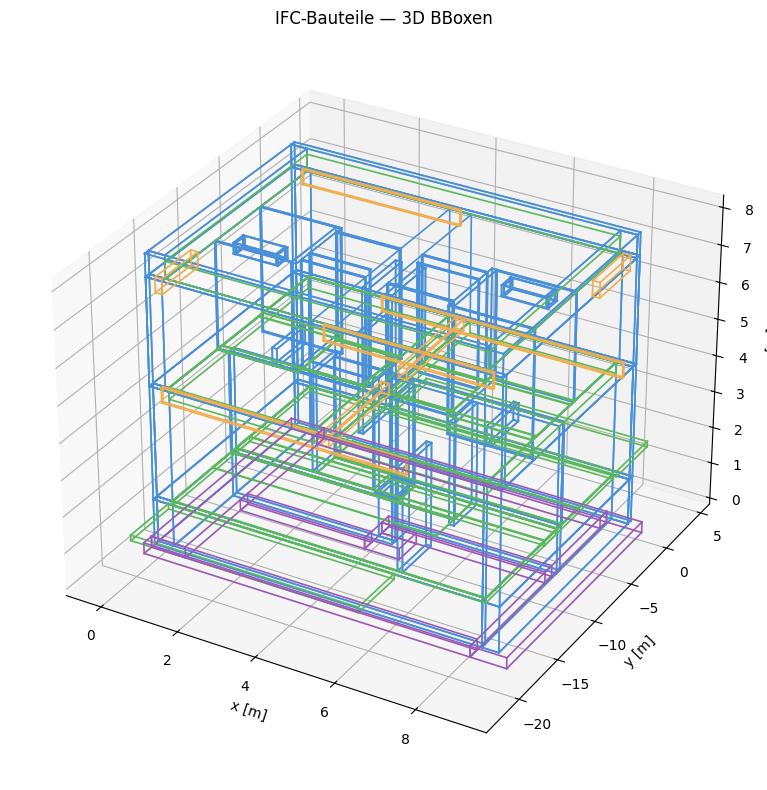

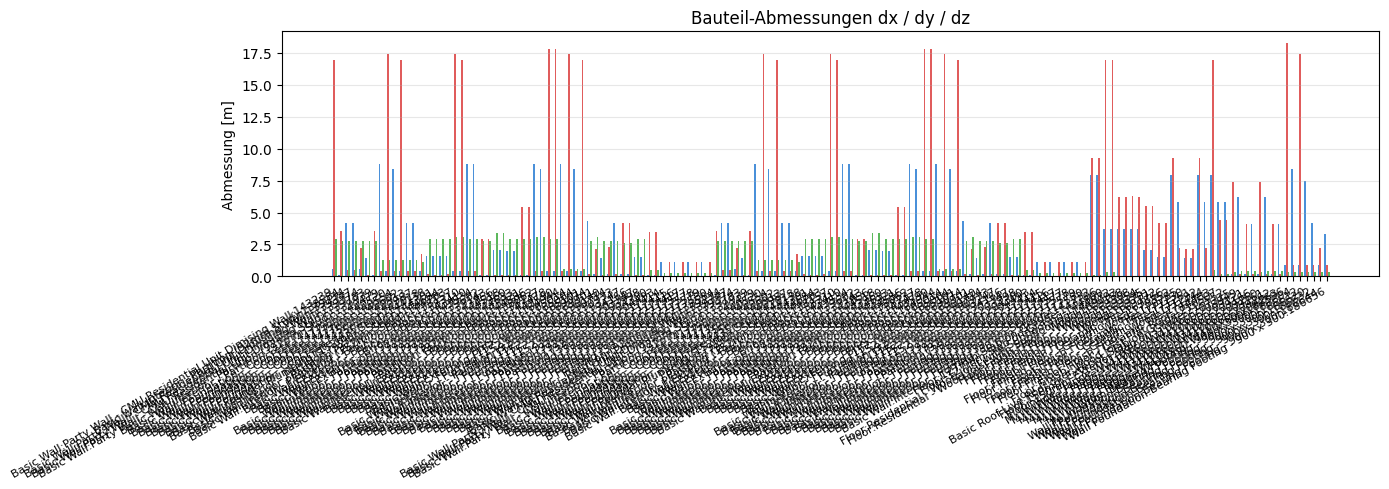

In [42]:
fig = plt.figure(figsize=(12, 8))
ax3d = fig.add_subplot(1, 1, 1, projection='3d')
_colors = [COLOR_MAP.get(e['label'], 'gray') for e in elements_raw]
for e, col in zip(elements_raw, _colors):
    bmin, bmax = e['bbox_min'], e['bbox_max']
    _verts = [
        [bmin[0],bmin[1],bmin[2]], [bmax[0],bmin[1],bmin[2]],
        [bmax[0],bmax[1],bmin[2]], [bmin[0],bmax[1],bmin[2]],
        [bmin[0],bmin[1],bmax[2]], [bmax[0],bmin[1],bmax[2]],
        [bmax[0],bmax[1],bmax[2]], [bmin[0],bmax[1],bmax[2]],
    ]
    _edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    for i1, i2 in _edges:
        ax3d.plot3D(*zip(_verts[i1], _verts[i2]), color=col, lw=1.2)
ax3d.set_xlabel('x [m]'); ax3d.set_ylabel('y [m]'); ax3d.set_zlabel('z [m]')
ax3d.set_title('IFC-Bauteile — 3D BBoxen', fontsize=12)
plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(14, 5))
names = [e['name'] for e in elements_raw]
dx = [e['dims'][0] for e in elements_raw]
dy = [e['dims'][1] for e in elements_raw]
dz = [e['dims'][2] for e in elements_raw]
x_pos = onp.arange(len(names))
w = 0.25
ax2.bar(x_pos - w, dx, w, color='#4a90d9')
ax2.bar(x_pos,     dy, w, color='#e05c5c')
ax2.bar(x_pos + w, dz, w, color='#5cb85c')
ax2.set_xticks(x_pos); ax2.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Abmessung [m]'); ax2.set_title('Bauteil-Abmessungen dx / dy / dz', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 4 — Visualisierung der semantischen Punktwolke

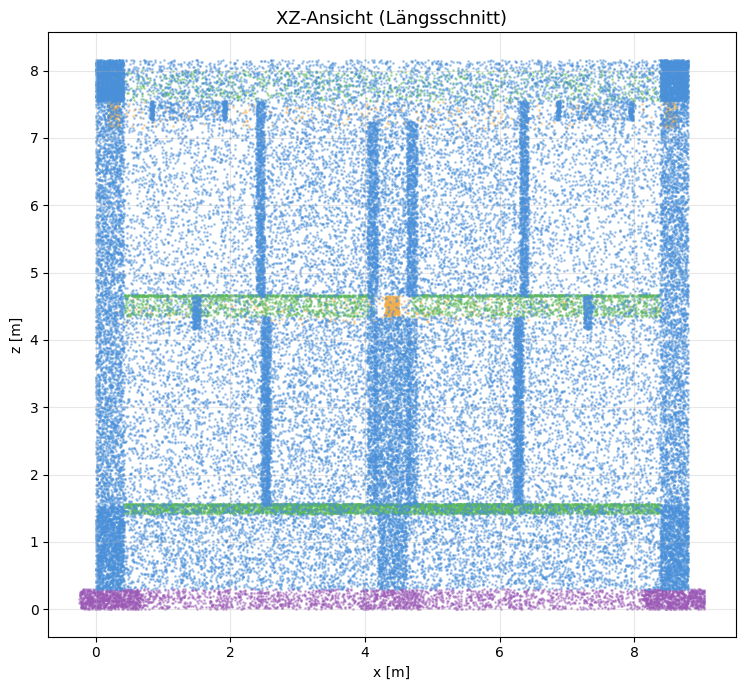

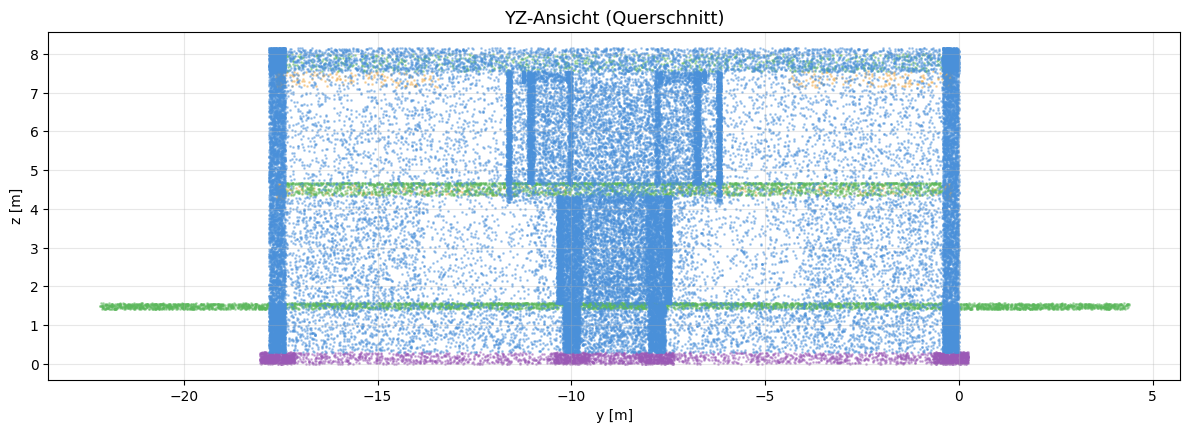

In [43]:
for x_col, z_col, xlabel, title in [
    (0, 2, 'x [m]', 'XZ-Ansicht (Längsschnitt)'),
    (1, 2, 'y [m]', 'YZ-Ansicht (Querschnitt)'),
]:
    fig, ax = plt.subplots(figsize=(12, 7))
    for lbl in onp.unique(cloud_labels):
        mask = (cloud_labels == lbl)
        pts  = cloud_pts[mask]
        ax.scatter(pts[:, x_col], pts[:, z_col], s=1,
                   c=COLOR_MAP.get(lbl, 'gray'), alpha=0.4)
    ax.set_xlabel(xlabel); ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=13); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5 — IFC-Relationship-Analyse

Drei Quellen für Graphkanten:

| IFC-Relationship | Kanten-Typ | Bedeutung |
|---|---|---|
| `IfcRelAggregates` | `part_of` / `contains` | Hierarchische Zerlegung |
| `IfcRelContainedInSpatialStructure` | `hosted_in` | Stockwerk-Zuordnung |
| `IfcRelAssociatesMaterial` | `shared_material` | Gleiches Material |
| BBox-Spatial (Schritt 6) | `above/adjacent/near` | Geometrische Lage |

In [44]:
def extract_ifc_relationships(ifc_model, elements_raw: List[Dict]) -> List[Tuple]:
    """Liest IFC-Relationships aus und gibt (name_a, name_b, rel_type) zurück."""
    # GUID → Name-Index für schnelle Suche
    guid_map = {e['guid']: e['name'] for e in elements_raw}
    rels = []

    # 1. IfcRelAggregates: hierarchische Zerlegung
    for rel in ifc_model.by_type('IfcRelAggregates'):
        whole = rel.RelatingObject
        if not hasattr(rel, 'RelatedObjects'): continue
        for part in rel.RelatedObjects:
            w_name = guid_map.get(getattr(whole, 'GlobalId', None))
            p_name = guid_map.get(getattr(part,  'GlobalId', None))
            if w_name and p_name:
                rels.append((w_name, p_name, 'contains'))

    # 2. IfcRelContainedInSpatialStructure: Stockwerk-Zuordnung
    #    Alle Bauteile im selben Stockwerk erhalten eine gemeinsame Kante
    storey_elements: Dict[str, List[str]] = {}
    for rel in ifc_model.by_type('IfcRelContainedInSpatialStructure'):
        storey = rel.RelatingStructure
        storey_name = getattr(storey, 'Name', str(storey))
        if not hasattr(rel, 'RelatedElements'): continue
        for elem in rel.RelatedElements:
            name = guid_map.get(getattr(elem, 'GlobalId', None))
            if name:
                storey_elements.setdefault(storey_name, []).append(name)

    # 3. IfcRelAssociatesMaterial: gemeinsames Material → Kante
    mat_elements: Dict[str, List[str]] = {}
    for rel in ifc_model.by_type('IfcRelAssociatesMaterial'):
        mat = rel.RelatingMaterial
        mat_name = getattr(mat, 'Name', str(mat))
        if not hasattr(rel, 'RelatedObjects'): continue
        for elem in rel.RelatedObjects:
            name = guid_map.get(getattr(elem, 'GlobalId', None))
            if name:
                mat_elements.setdefault(mat_name, []).append(name)

    for mat_name, names in mat_elements.items():
        for i in range(len(names)):
            for j in range(i+1, len(names)):
                rels.append((names[i], names[j], 'shared_material'))

    return rels, storey_elements


ifc_rels, storey_map = extract_ifc_relationships(ifc_model, elements_raw)

print('IFC-Relationships:')
if ifc_rels:
    for a, b, r in ifc_rels:
        print(f'  {a:20s}  --[{r}]-->  {b}')
else:
    print('  (keine direkten IFC-Relationships zwischen Bauteilen)')

print('\nStockwerk-Zuordnung:')
for storey, names in storey_map.items():
    print(f'  {storey}: {names}')

IFC-Relationships:
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:208949
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209121
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209166
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W310X60:W310X60:209260
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209261
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209262
  M_W-Wide Flange:W310X60:W310X60:207325  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209263
  M_W-Wide Flange:W410X60:W410X60:208949  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209121
  M_W-Wide Flange:W410X60:W410X60:208949  --[shared_material]-->  M_W-Wide Flange:W410X60:W410X60:209166
  M_W-Wide Flange:W410X60:W410X60:20

### Visualisierung: Relationship-Typen + Stockwerk

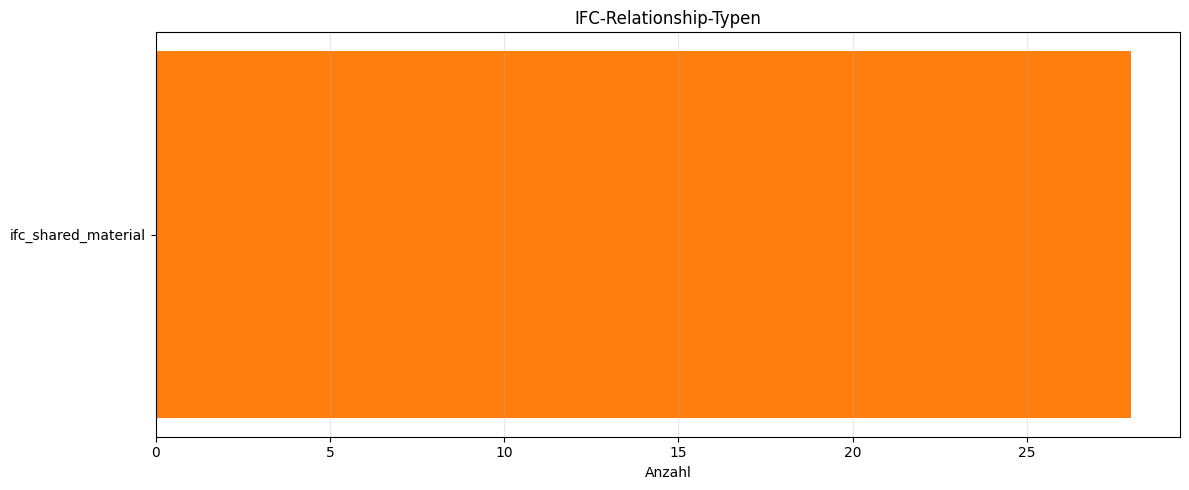

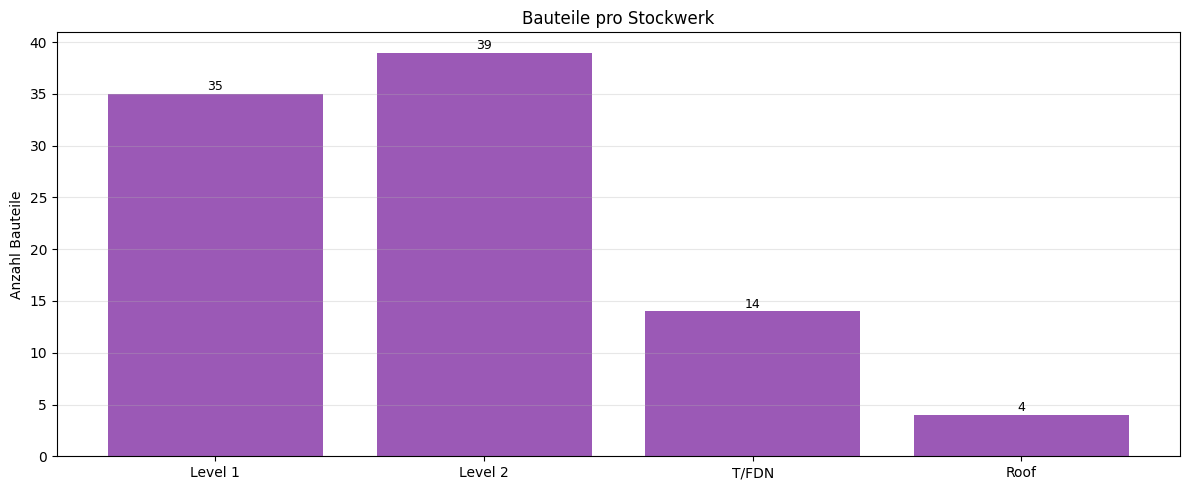

In [45]:
all_rel_cts: Dict[str, int] = {}
for _, _, r in ifc_rels:
    lbl = f'ifc_{r}'
    all_rel_cts[lbl] = all_rel_cts.get(lbl, 0) + 1

if all_rel_cts:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(list(all_rel_cts.keys()), list(all_rel_cts.values()),
            color=['#ff7f0e' if 'ifc' in k else '#4a90d9' for k in all_rel_cts])
    ax.set_xlabel('Anzahl'); ax.set_title('IFC-Relationship-Typen', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

storey_names  = list(storey_map.keys())
storey_counts = [len(v) for v in storey_map.values()]
if storey_names:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(storey_names, storey_counts, color='#9b59b6')
    ax.set_ylabel('Anzahl Bauteile'); ax.set_title('Bauteile pro Stockwerk', fontsize=12)
    for i, (n, c) in enumerate(zip(storey_names, storey_counts)):
        ax.text(i, c + 0.05, str(c), ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


## 6 — Semantisches Clustering (DBSCAN pro Label)

Analog Poux & Lehtola (2025), Step 4:
Für jedes semantisches Label wird DBSCAN auf die zugehörigen Punkte angewendet,
um diskrete Objekt-Instanzen zu ermitteln.  
Anschließend werden die geclusterten Objekte zurück auf die exakten IFC-BBoxen gesnapped.

In [46]:
def cluster_semantic_objects(
    pts: onp.ndarray,
    labels: onp.ndarray,
    eps: float = DBSCAN_EPS,
    min_samples: int = DBSCAN_MIN_SAMPLES,
) -> Dict:
    objects = {}
    for lbl in onp.unique(labels):
        mask   = (labels == lbl)
        l_pts  = pts[mask]
        if len(l_pts) < min_samples:
            continue
        cl = DBSCAN(eps=eps, min_samples=min_samples).fit(l_pts)
        for cid in onp.unique(cl.labels_):
            if cid == -1:
                continue
            c_pts = l_pts[cl.labels_ == cid]
            key   = f'{lbl}_{cid}'
            objects[key] = {
                'points'        : c_pts,
                'centroid'      : c_pts.mean(axis=0),
                'bounds_min'    : c_pts.min(axis=0),
                'bounds_max'    : c_pts.max(axis=0),
                'semantic_label': str(lbl),
                'point_count'   : len(c_pts),
            }
    return objects


def snap_to_ifc_bboxes(objects: Dict, elements_raw: List[Dict]) -> Dict:
    """Ersetzt Cluster-BBoxen durch exakte IFC-BBoxen + Material-Properties."""
    used = set()
    for name, obj in objects.items():
        lbl       = obj['semantic_label']
        centroid  = onp.asarray(obj['centroid'], dtype=float)
        candidates = [
            (i, e) for i, e in enumerate(elements_raw)
            if e['label'] == lbl and i not in used
        ]
        if not candidates:
            continue
        best_i, best = min(
            candidates,
            key=lambda ie: onp.linalg.norm(
                centroid - ie[1]['centroid']
            )
        )
        used.add(best_i)
        obj['bounds_min'] = best['bbox_min'].astype(float).copy()
        obj['bounds_max'] = best['bbox_max'].astype(float).copy()
        obj['centroid']   = 0.5 * (obj['bounds_min'] + obj['bounds_max'])
        obj['dims']       = best['dims'].astype(float).copy()
        obj['origin']     = best['origin'].astype(float).copy()
        obj['E']          = best['E']
        obj['nu']         = best['nu']
        obj['ifc_name']   = best['name']
        obj['ifc_guid']   = best['guid']
        obj['ifc_class']  = best['ifc_class']
    return objects


# ── Direkter IFC-Bypass bei echten IFC-Daten ─────────────────────
# Die IFC-Geometrie ist bereits segmentiert — kein Re-Clustering nötig.
# DBSCAN nur für Demo-Modell (synthetische Punktwolke).
if USE_DEMO_MODEL:
    objects = cluster_semantic_objects(cloud_pts, cloud_labels)
    objects = snap_to_ifc_bboxes(objects, elements_raw)
else:
    objects = {}
    for elem in elements_raw:
        key = f'{elem["label"]}_{elem["guid"][:8]}'
        objects[key] = {
            'points'        : onp.array([elem['centroid']]),
            'centroid'      : elem['centroid'].copy(),
            'bounds_min'    : elem['bbox_min'].copy(),
            'bounds_max'    : elem['bbox_max'].copy(),
            'dims'          : elem['dims'].copy(),
            'origin'        : elem['origin'].copy(),
            'semantic_label': elem['label'],
            'point_count'   : 1,
            'E'             : elem['E'],
            'nu'            : elem['nu'],
            'ifc_name'      : elem['name'],
            'ifc_guid'      : elem['guid'],
            'ifc_class'     : elem['ifc_class'],
        }

print(f'{len(objects)} Objekte nach Clustering + IFC-Snap:')
print(f'{"Key":18s}  {"IFC-Name":15s}  {"Label":8s}  '
      f'{"BBox [m]"}          E [kN/m²]')
print('-' * 75)
for k, obj in objects.items():
    d = obj['bounds_max'] - obj['bounds_min']
    print(f'  {k:16s}  {obj.get("ifc_name","?"):15s}  '
          f'{obj["semantic_label"]:8s}  '
          f'{d[0]:.2f}x{d[1]:.2f}x{d[2]:.2f}   '
          f'{obj.get("E", E_DEFAULT):.0f}')


13 Objekte nach Clustering + IFC-Snap:
Key                 IFC-Name         Label     BBox [m]          E [kN/m²]
---------------------------------------------------------------------------
  wall_2O2Fr$t4     Basic Wall:Exterior - Brick on Block:143590  wall      0.42x17.80x2.90   30000000
  wall_0jf0rYHf     Basic Wall:Exterior - Brick on Block:185101  wall      0.42x16.97x0.61   30000000
  wall_0iEHWY1$     Basic Wall:Interior - Furring (152 mm Stud):190933  wall      4.20x0.15x2.80   30000000
  wall_0dxE1Sy6     Basic Wall:Interior - Furring (152 mm Stud):194166  wall      0.15x4.16x2.60   30000000
  wall_1aj$VJZF     Basic Wall:Interior - Partition (92mm Stud):204493  wall      0.12x3.48x0.49   30000000
  wall_3Y4YRln2     Basic Wall:Interior - Furring (38 mm Stud):217580  wall      0.05x1.14x0.29   30000000
  slab_2O2Fr$t4     Floor:127mm Slab on Grade:143106  slab      7.97x9.31x0.13   30000000
  slab_1hOSvn6d     Floor:Residential - Wood Joist with Subflooring:144872  slab     

### Visualisierung: DBSCAN-Cluster-Instanzen

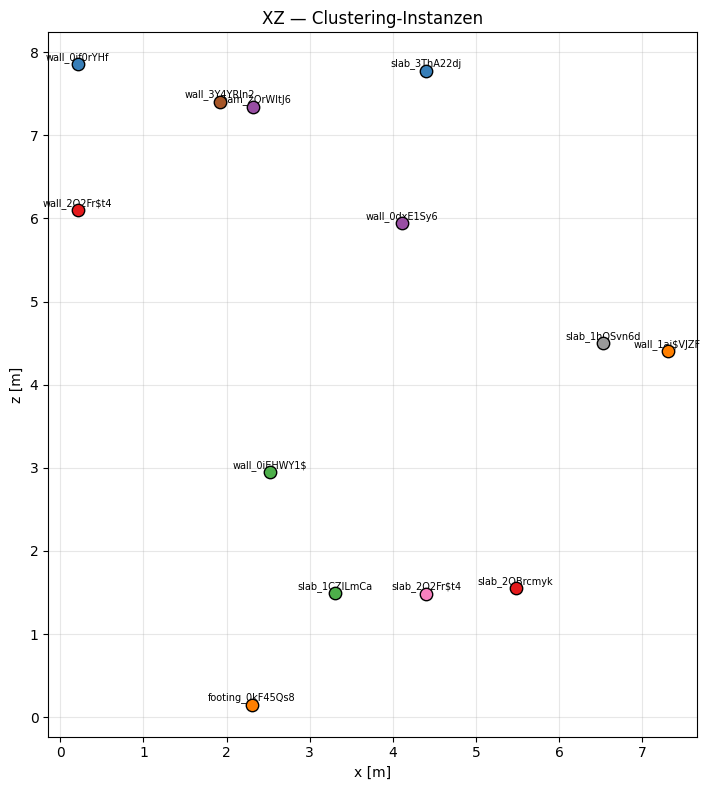

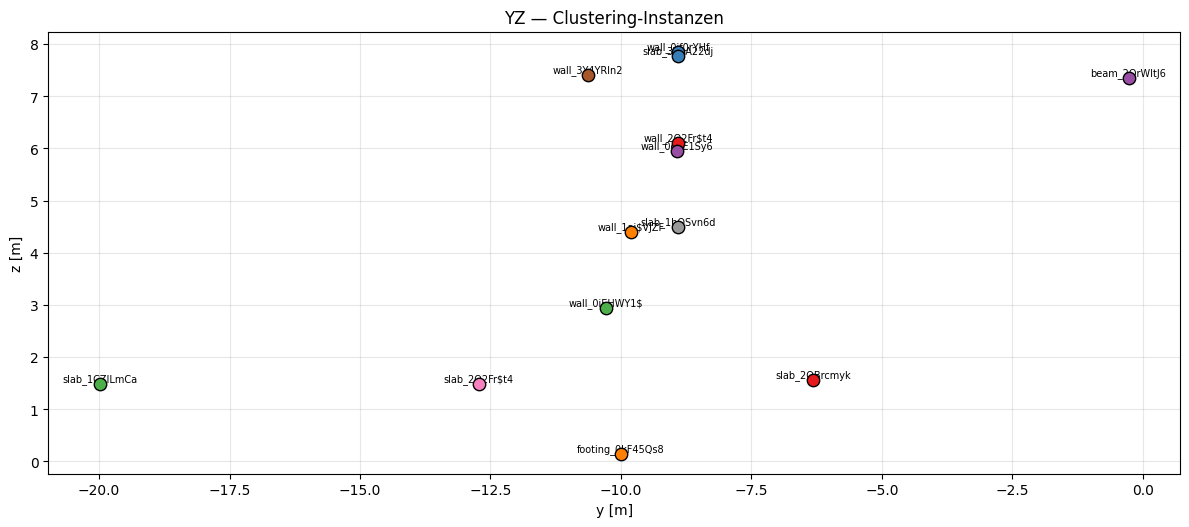

In [47]:
CLUSTER_PALETTE = [
    '#e41a1c','#377eb8','#4daf4a','#984ea3',
    '#ff7f00','#a65628','#f781bf','#999999',
]

for x_col, z_col, xlabel, title in [
    (0, 2, 'x [m]', 'XZ — Clustering-Instanzen'),
    (1, 2, 'y [m]', 'YZ — Clustering-Instanzen'),
]:
    fig, ax = plt.subplots(figsize=(12, 8))
    for ci, (key, obj) in enumerate(objects.items()):
        col   = CLUSTER_PALETTE[ci % len(CLUSTER_PALETTE)]
        c_pts = obj['points']
        ax.scatter(c_pts[:, x_col], c_pts[:, z_col], s=1, c=col, alpha=0.5)
        cx = obj['centroid'][x_col]; cz = obj['centroid'][z_col]
        ax.scatter(cx, cz, s=80, c=col, edgecolors='black', zorder=5)
        ax.text(cx, cz + 0.05, key, fontsize=7, ha='center')
    ax.set_xlabel(xlabel); ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=12); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## 7 — Objekt-Feature-Extraktion

Analog Poux & Lehtola (2025), Step 6:
Volumen (BBox), Oberfläche (konvexe Hülle), Kompaktheit, Höhe.

In [48]:
def surface_area(pts: onp.ndarray) -> float:
    try: return float(ConvexHull(pts).area)
    except Exception: return 0.0


def compute_features(objects: Dict) -> Dict:
    features = {}
    for name, obj in objects.items():
        dims    = obj['bounds_max'] - obj['bounds_min']
        vol     = float(onp.prod(dims))
        sa      = surface_area(obj['points'])
        compact = (sa**3) / (36 * onp.pi * vol**2) if vol > 0 else 0.0
        features[name] = {
            'volume'        : vol,
            'surface_area'  : sa,
            'compactness'   : compact,
            'height'        : float(dims[2]),
            'aspect_ratio'  : float(max(dims) / (min(dims) + 1e-9)),
            'semantic_label': obj['semantic_label'],
            'centroid'      : obj['centroid'],
            'point_density' : obj['point_count'] / vol if vol > 0 else 0.0,
        }
    return features


features = compute_features(objects)

print(f'{"Objekt":18s}  {"Vol [m³]":>10s}  '
      f'{"Höhe [m]":>8s}  {"Komp."}  Aspekt')
print('-' * 60)
for n, f in features.items():
    print(f'  {n:16s}  {f["volume"]:>10.3f}  '
          f'{f["height"]:>8.2f}  {f["compactness"]:6.2f}  '
          f'{f["aspect_ratio"]:5.1f}')

Objekt                Vol [m³]  Höhe [m]  Komp.  Aspekt
------------------------------------------------------------
  wall_2O2Fr$t4         21.526      2.90    0.00   42.7
  wall_0jf0rYHf          4.309      0.61    0.00   40.7
  wall_0iEHWY1$          1.785      2.80    0.00   27.6
  wall_0dxE1Sy6          1.641      2.60    0.00   27.4
  wall_1aj$VJZF          0.210      0.49    0.00   28.0
  wall_3Y4YRln2          0.018      0.29    0.00   21.0
  slab_2O2Fr$t4          9.417      0.13    0.00   73.3
  slab_1hOSvn6d         19.188      0.31    0.00   55.6
  slab_2OBrcmyk          0.168      0.01    0.00  446.8
  slab_3ThA22dj         61.764      0.46    0.00   37.1
  slab_1CZILmCa          3.813      0.15    0.00   38.7
  beam_2OrWItJ6          0.297      0.41    0.00   23.0
  footing_0kF45Qs8       0.889      0.30    0.00   11.0


### Visualisierung: Feature-Profil

/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_39512/3643660019.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names_f, rotation=30, ha='right', fontsize=8)


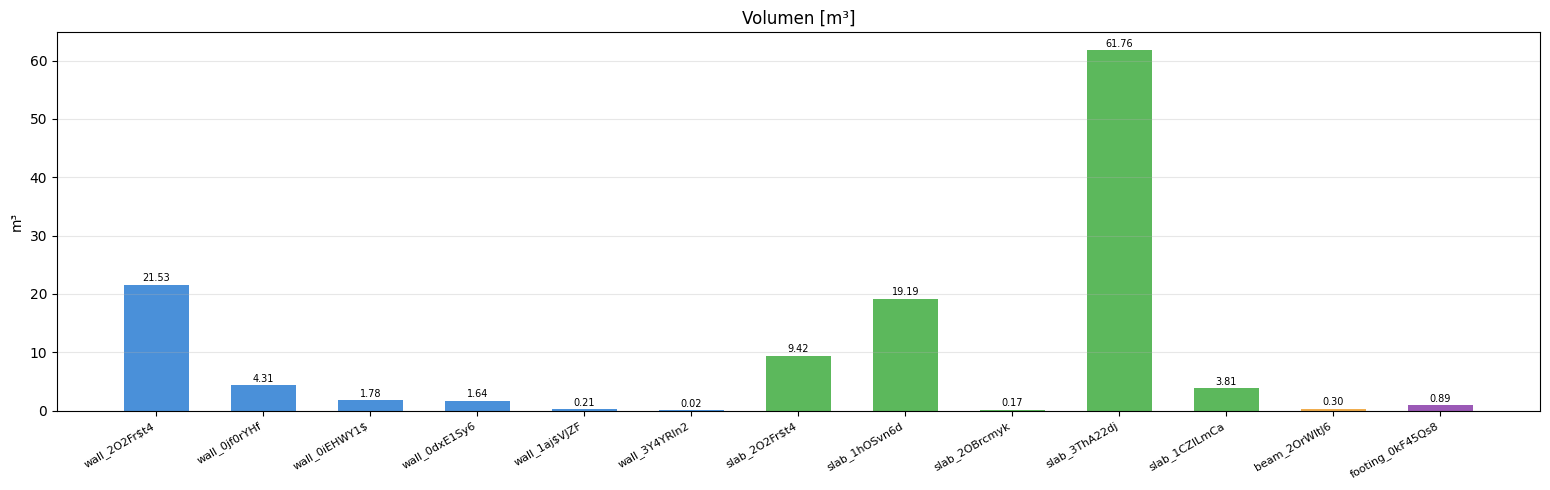

/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_39512/3643660019.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names_f, rotation=30, ha='right', fontsize=8)


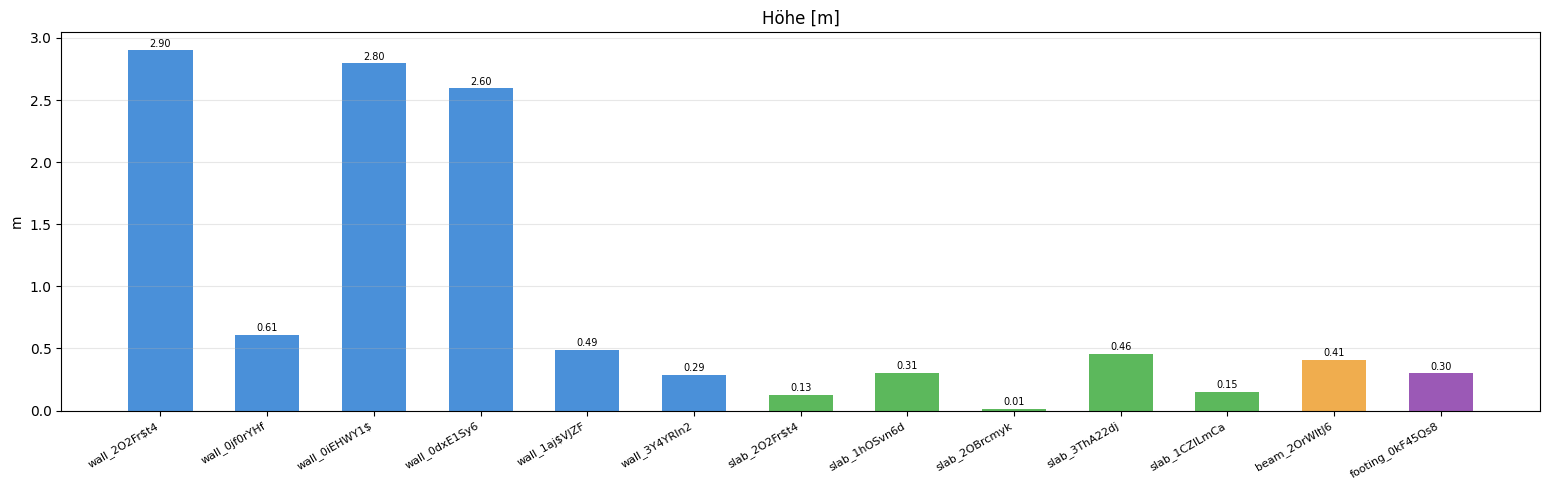

/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_39512/3643660019.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names_f, rotation=30, ha='right', fontsize=8)


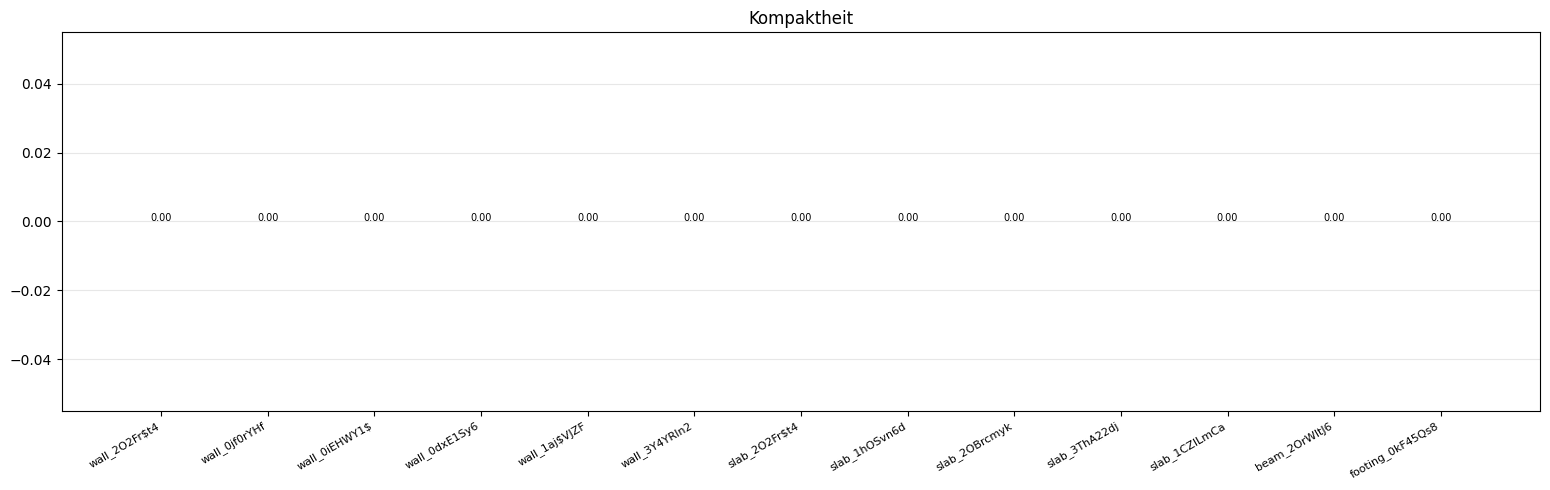

/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_39512/3643660019.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names_f, rotation=30, ha='right', fontsize=8)


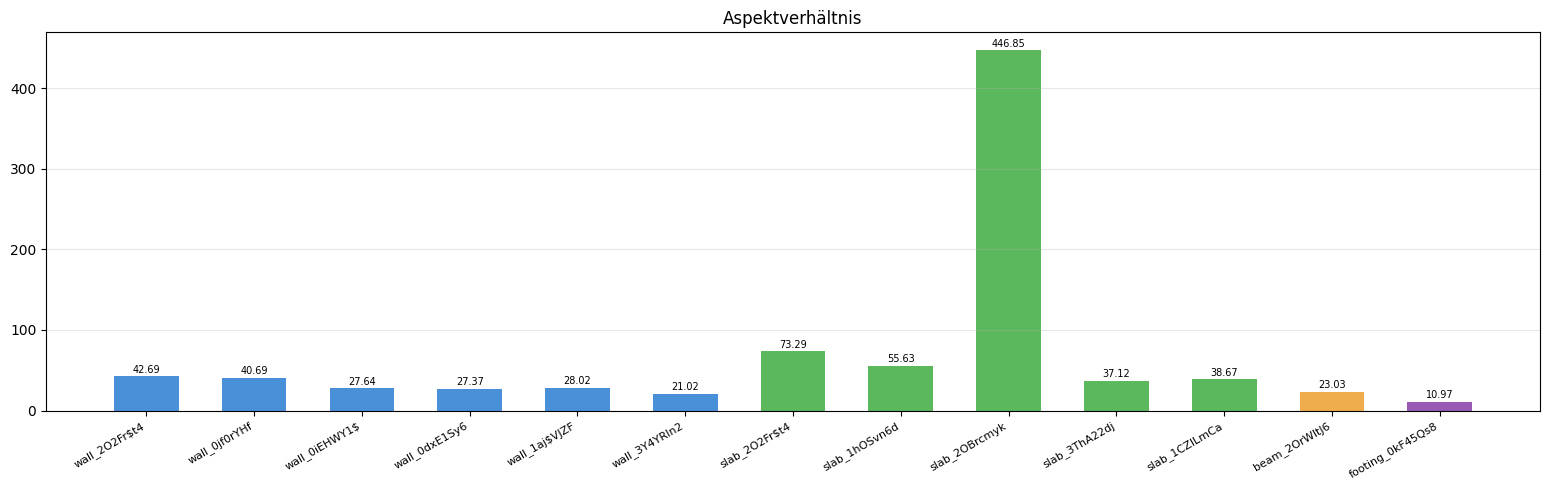

In [49]:
names_f = list(features.keys())
cols_f  = [COLOR_MAP.get(features[n]['semantic_label'], '#aaa') for n in names_f]

for vals, ylabel, title in [
    ([features[n]['volume']      for n in names_f], 'm³',    'Volumen [m³]'),
    ([features[n]['height']      for n in names_f], 'm',     'Höhe [m]'),
    ([features[n]['compactness'] for n in names_f], '',      'Kompaktheit'),
    ([features[n]['aspect_ratio']for n in names_f], '',      'Aspektverhältnis'),
]:
    fig, ax = plt.subplots(figsize=(max(10, len(names_f)*1.2), 5))
    bars = ax.bar(names_f, vals, color=cols_f, width=0.6)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=12)
    ax.set_xticklabels(names_f, rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + abs(max(vals, key=abs))*0.01,
                f'{val:.2f}', ha='center', fontsize=7)
    plt.tight_layout(); plt.show()


## 8 — Räumliche Beziehungsanalyse

Drei-Stufen-Algorithmus auf BBox-Basis:

1. **Vertikal:** `above`/`below` bei Höhenunterschied > 0,5 m
2. **Containment:** Ist ein Objekt vollständig in einem anderen?
3. **Adjacency:** Berühren sich die BBoxen (Toleranz `ADJ_TOLERANCE`)?
4. **Fallback:** `near` bei Distanz < `REL_THRESHOLD`

IFC-Relationships aus Schritt 5 werden ergänzt.

In [50]:
def is_contained(bmin1, bmax1, bmin2, bmax2) -> bool:
    return bool(onp.all(bmin1 >= bmin2) and onp.all(bmax1 <= bmax2))


def are_adjacent(bmin1, bmax1, bmin2, bmax2, tol=ADJ_TOLERANCE) -> bool:
    for ax in range(3):
        if (abs(bmax1[ax] - bmin2[ax]) < tol or
                abs(bmax2[ax] - bmin1[ax]) < tol):
            return True
    return False


def classify_spatial_rel(obj1, obj2, threshold=REL_THRESHOLD) -> Optional[str]:
    d = onp.linalg.norm(obj1['centroid'] - obj2['centroid'])
    if d > threshold: return None
    bmin1, bmax1 = obj1['bounds_min'], obj1['bounds_max']
    bmin2, bmax2 = obj2['bounds_min'], obj2['bounds_max']
    dz = float(obj1['centroid'][2] - obj2['centroid'][2])
    if abs(dz) > 0.5: return 'above' if dz > 0 else 'below'
    if is_contained(bmin1, bmax1, bmin2, bmax2): return 'inside'
    if is_contained(bmin2, bmax2, bmin1, bmax1): return 'contains'
    if are_adjacent(bmin1, bmax1, bmin2, bmax2): return 'adjacent'
    return 'near'


def compute_all_relationships(objects: Dict, ifc_rels: List) -> List[Tuple]:
    """Kombiniert geometrische + IFC-Relationships."""
    # Lookup: IFC-Name → Cluster-Key
    name_to_key = {obj.get('ifc_name', k): k for k, obj in objects.items()}

    rels = []
    seen = set()

    # IFC-Relationships einbinden
    for a_name, b_name, rel_type in ifc_rels:
        a_key = name_to_key.get(a_name)
        b_key = name_to_key.get(b_name)
        if a_key and b_key and a_key != b_key:
            pair = tuple(sorted([a_key, b_key]))
            if pair not in seen:
                rels.append((a_key, b_key, f'ifc_{rel_type}'))
                seen.add(pair)

    # Geometrische Spatial-Relationships
    names = list(objects.keys())
    for i, n1 in enumerate(names):
        for n2 in names[i+1:]:
            pair = tuple(sorted([n1, n2]))
            if pair in seen:
                continue
            rel = classify_spatial_rel(objects[n1], objects[n2])
            if rel:
                rels.append((n1, n2, rel))
                seen.add(pair)
    return rels


relationships = compute_all_relationships(objects, ifc_rels)

rel_counts: Dict[str, int] = {}
print(f'{len(relationships)} Beziehungen:')
for o1, o2, rel in relationships:
    rel_counts[rel] = rel_counts.get(rel, 0) + 1
    print(f'  {o1:18s}  --[{rel}]-->  {o2}')
print(f'\nTypen: {rel_counts}')

24 Beziehungen:
  wall_2O2Fr$t4       --[below]-->  wall_0jf0rYHf
  wall_2O2Fr$t4       --[above]-->  wall_0iEHWY1$
  wall_2O2Fr$t4       --[near]-->  wall_0dxE1Sy6
  wall_2O2Fr$t4       --[below]-->  wall_3Y4YRln2
  wall_2O2Fr$t4       --[below]-->  slab_3ThA22dj
  wall_0jf0rYHf       --[above]-->  wall_0dxE1Sy6
  wall_0jf0rYHf       --[adjacent]-->  wall_3Y4YRln2
  wall_0jf0rYHf       --[adjacent]-->  slab_3ThA22dj
  wall_0iEHWY1$       --[below]-->  wall_0dxE1Sy6
  wall_0iEHWY1$       --[below]-->  wall_3Y4YRln2
  wall_0iEHWY1$       --[above]-->  slab_2O2Fr$t4
  wall_0iEHWY1$       --[below]-->  slab_1hOSvn6d
  wall_0iEHWY1$       --[above]-->  footing_0kF45Qs8
  wall_0dxE1Sy6       --[above]-->  wall_1aj$VJZF
  wall_0dxE1Sy6       --[below]-->  wall_3Y4YRln2
  wall_0dxE1Sy6       --[above]-->  slab_1hOSvn6d
  wall_0dxE1Sy6       --[below]-->  slab_3ThA22dj
  wall_1aj$VJZF       --[near]-->  slab_1hOSvn6d
  wall_1aj$VJZF       --[above]-->  slab_2OBrcmyk
  wall_1aj$VJZF       --[be

### Visualisierung: Räumliche Beziehungen

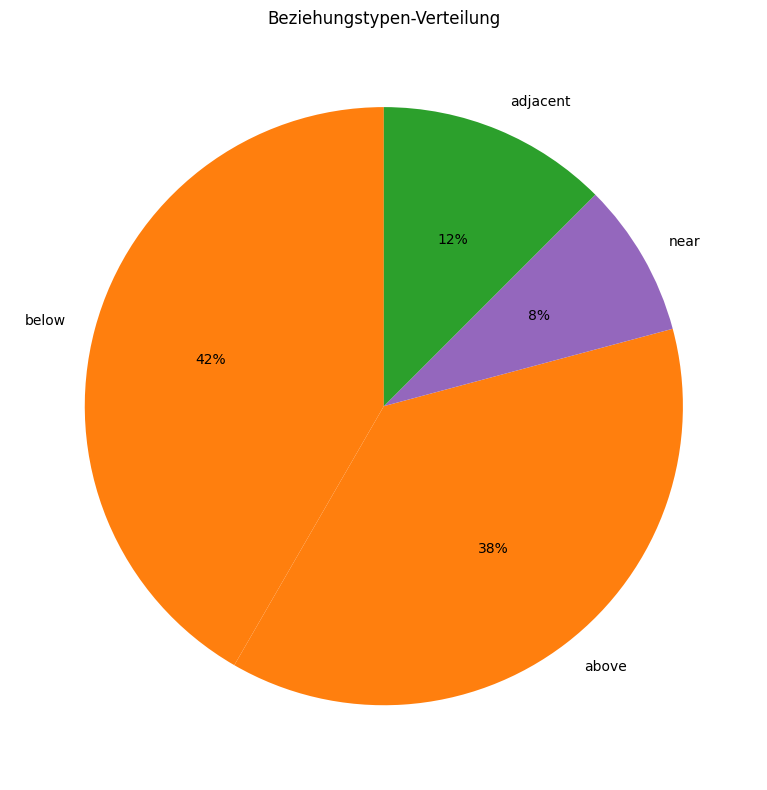

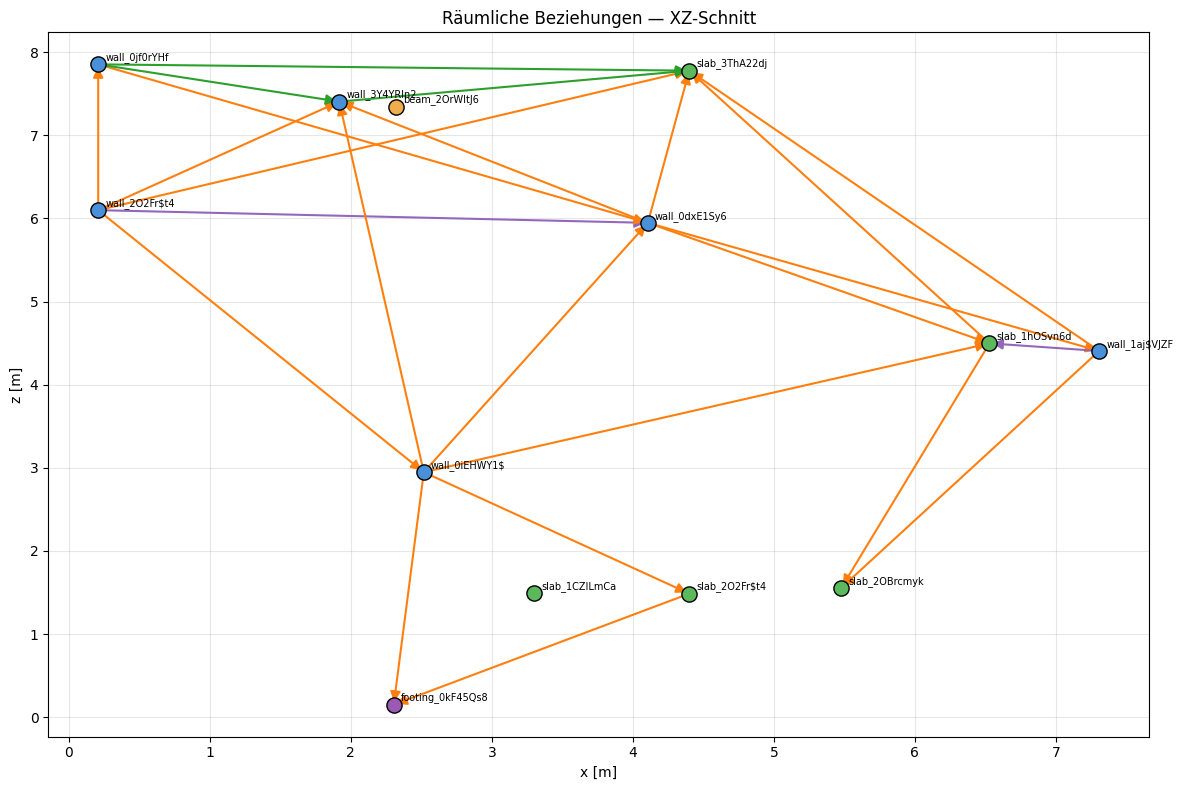

In [51]:
rel_types_all: Dict[str, int] = {}
for _, _, r in relationships:
    rel_types_all[r] = rel_types_all.get(r, 0) + 1

if rel_types_all:
    fig, ax = plt.subplots(figsize=(8, 8))
    _labels = list(rel_types_all.keys())
    _sizes  = list(rel_types_all.values())
    _colors = [EDGE_COLORS.get(l, '#888') for l in _labels]
    ax.pie(_sizes, labels=_labels, colors=_colors, autopct='%1.0f%%',
           startangle=90, textprops={'fontsize': 10})
    ax.set_title('Beziehungstypen-Verteilung', fontsize=12)
    plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
for key, obj in objects.items():
    col = COLOR_MAP.get(obj['semantic_label'], 'gray')
    cx, cz = obj['centroid'][0], obj['centroid'][2]
    ax.scatter(cx, cz, s=120, c=col, zorder=4, edgecolors='black')
    ax.text(cx + 0.05, cz + 0.05, key, fontsize=7, zorder=5)
for o1, o2, rel in relationships:
    if o1 not in objects or o2 not in objects: continue
    x1, z1 = objects[o1]['centroid'][0], objects[o1]['centroid'][2]
    x2, z2 = objects[o2]['centroid'][0], objects[o2]['centroid'][2]
    col = EDGE_COLORS.get(rel, '#888')
    ax.annotate('', xy=(x2, z2), xytext=(x1, z1),
                 arrowprops=dict(arrowstyle='-|>', color=col, lw=1.5, mutation_scale=15))
ax.set_xlabel('x [m]'); ax.set_ylabel('z [m]')
ax.set_title('Räumliche Beziehungen — XZ-Schnitt', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9 — Scene Graph aufbauen (NetworkX DiGraph)

Jeder Knoten enthält:
- Semantisches Label, IFC-Name, GUID
- BBox, Schwerpunkt, Volumen, Höhe
- E-Modul, Querdehnzahl (aus IFC)
- Feature-Werte (Kompaktheit, Aspektverhältnis)

Kanten tragen `relationship` + `source` (geometric / ifc).

In [52]:
def build_scene_graph(
    objects: Dict, relationships: List, features: Dict
) -> nx.DiGraph:
    G = nx.DiGraph()
    for name, obj in objects.items():
        f = features.get(name, {})
        G.add_node(
            name,
            semantic_label = obj['semantic_label'],
            ifc_name       = obj.get('ifc_name', name),
            ifc_guid       = obj.get('ifc_guid', ''),
            ifc_class      = obj.get('ifc_class', ''),
            centroid       = obj['centroid'].tolist(),
            bounds_min     = obj['bounds_min'].tolist(),
            bounds_max     = obj['bounds_max'].tolist(),
            volume         = f.get('volume', 0.0),
            height         = f.get('height', 0.0),
            compactness    = f.get('compactness', 0.0),
            aspect_ratio   = f.get('aspect_ratio', 1.0),
            E_kNm2         = obj.get('E', E_DEFAULT),
            nu             = obj.get('nu', NU_DEFAULT),
            point_count    = obj['point_count'],
        )
    for o1, o2, rel in relationships:
        src = 'ifc' if rel.startswith('ifc_') else 'geometric'
        rel_clean = rel.replace('ifc_', '')
        G.add_edge(o1, o2, relationship=rel_clean, source=src)
    return G


G = build_scene_graph(objects, relationships, features)

print(f'Scene Graph: {G.number_of_nodes()} Knoten, {G.number_of_edges()} Kanten')
print(f'Zusammenhang: {nx.number_weakly_connected_components(G)} Komponente(n)')
sem_dist = {}
for _, d in G.nodes(data=True): sem_dist[d['semantic_label']] = sem_dist.get(d['semantic_label'], 0) + 1
print(f'Knotenverteilung: {sem_dist}')
print(f'Durchschnittlicher Grad: {sum(d for _,d in G.degree())/G.number_of_nodes():.2f}')

Scene Graph: 13 Knoten, 24 Kanten
Zusammenhang: 3 Komponente(n)
Knotenverteilung: {'wall': 6, 'slab': 5, 'beam': 1, 'footing': 1}
Durchschnittlicher Grad: 3.69


## 10 — Scene Graph visualisieren

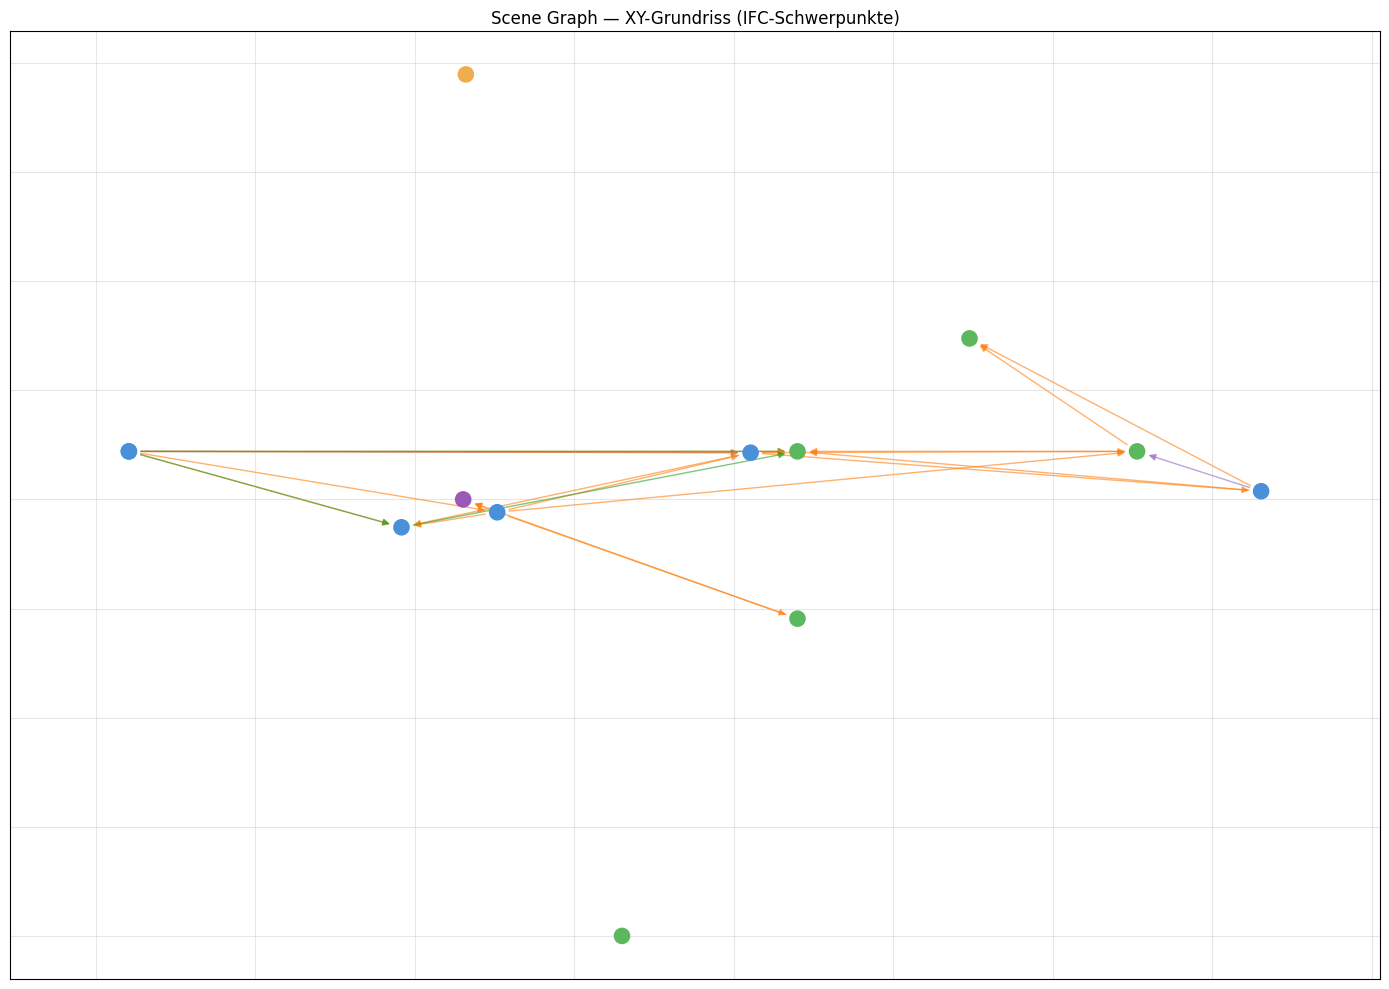

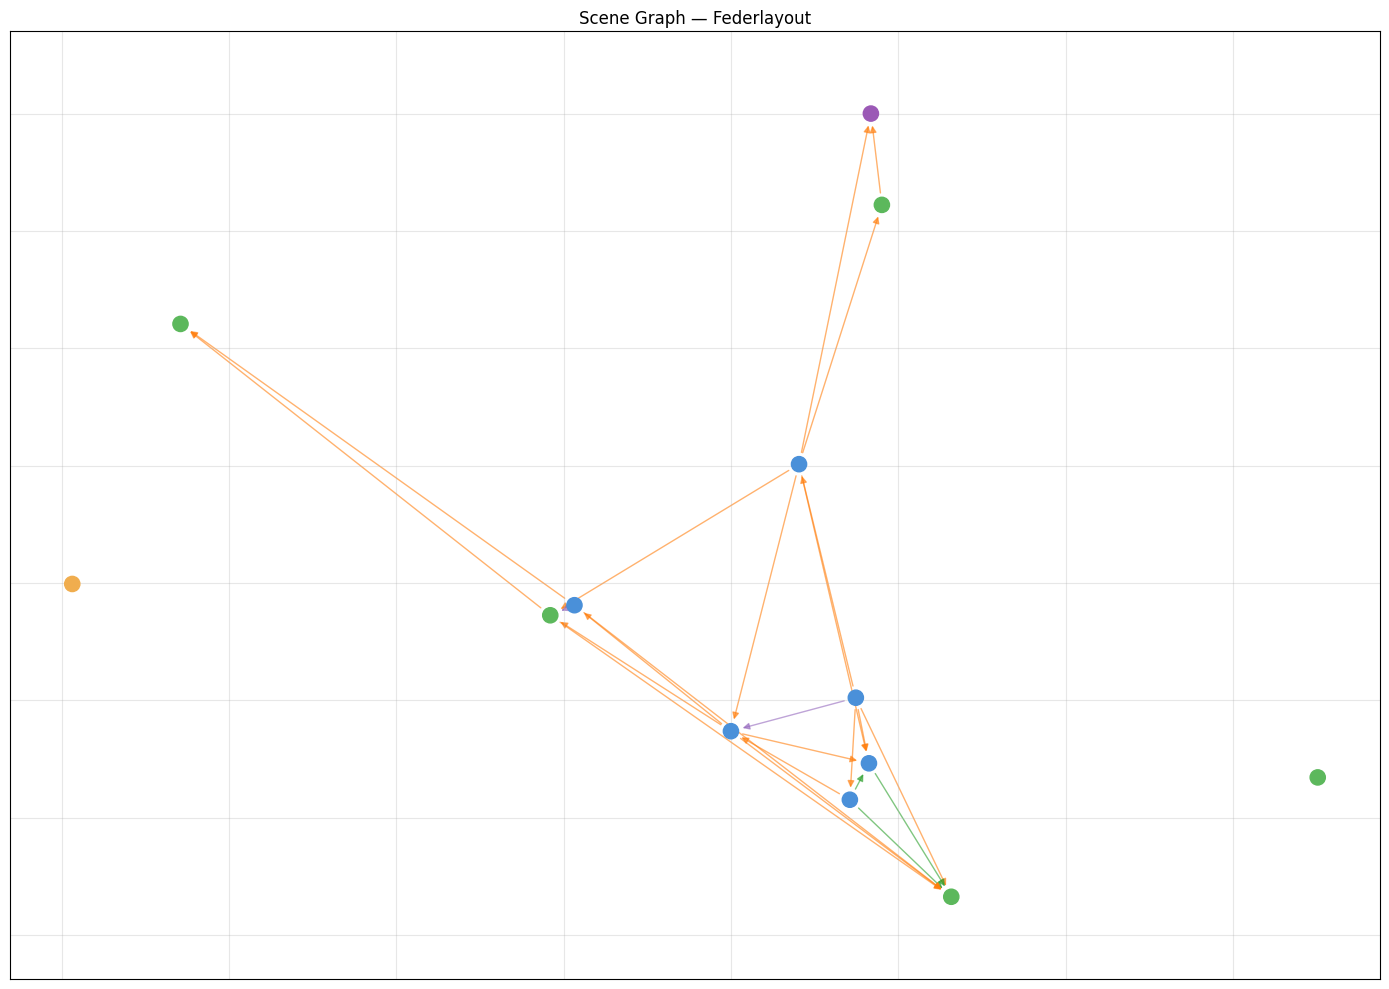

In [53]:
pos_xy = {
    node: (data['centroid'][0], data['centroid'][1])
    for node, data in G.nodes(data=True)
}
pos_sp = nx.spring_layout(G, seed=42)

node_colors = [NODE_COLORS.get(G.nodes[n]['semantic_label'], '#aaa') for n in G.nodes]
edge_colors = [EDGE_COLORS.get(G.edges[e]['relationship'], '#888') for e in G.edges]

for pos, title in [(pos_xy, 'Scene Graph — XY-Grundriss (IFC-Schwerpunkte)'),
                   (pos_sp, 'Scene Graph — Federlayout')]:
    fig, ax = plt.subplots(figsize=(14, 10))
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=120)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors,
                          arrows=True, arrowsize=10, width=1, alpha=0.6)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## 11 — Graphanalyse: Randbedingungen + Lastflächen

| Graph-Eigenschaft | FEM-Ableitung |
|---|---|
| `wall`/`column` ohne eingehende `below`-Kante | Einspannung am Fuß (z = z_min) |
| `slab` mit ausgehender `above`-Kante zu Wand/Stütze | Lastfläche oben |
| `slab` auf höchster z-Ebene | Primäre Lastauflagefläche |

In [54]:
def analyze_graph(G: nx.DiGraph) -> Dict:
    info = {
        'n_nodes'           : G.number_of_nodes(),
        'n_edges'           : G.number_of_edges(),
        'semantic_dist'     : {},
        'rel_types'         : {},
        'foundation_nodes'  : [],  # Einspannung
        'load_surface_nodes': [],  # Lastfläche
        'ifc_edge_count'    : 0,
        'geo_edge_count'    : 0,
    }
    for _, _, ed in G.edges(data=True):
        r = ed.get('relationship', '?')
        info['rel_types'][r] = info['rel_types'].get(r, 0) + 1
        if ed.get('source') == 'ifc': info['ifc_edge_count'] += 1
        else: info['geo_edge_count'] += 1

    for node, data in G.nodes(data=True):
        lbl = data['semantic_label']
        info['semantic_dist'][lbl] = info['semantic_dist'].get(lbl, 0) + 1

        # Einspannung: tragende Elemente ohne Auflager darunter
        if lbl in ('wall', 'column', 'footing'):
            has_support = any(
                G.edges[e]['relationship'] == 'below'
                for e in G.in_edges(node)
            )
            if not has_support:
                info['foundation_nodes'].append(node)

        # Lastfläche: Decken die über Wände/Stützen liegen
        if lbl == 'slab':
            bears_above = any(
                G.edges[e]['relationship'] in ('above', 'adjacent')
                for e in G.out_edges(node)
            )
            if bears_above:
                info['load_surface_nodes'].append(node)

    # Fallback: alle Decken als Lastfläche
    if not info['load_surface_nodes']:
        info['load_surface_nodes'] = [
            n for n, d in G.nodes(data=True) if d['semantic_label'] == 'slab'
        ]
    return info


sg_info = analyze_graph(G)

print('=== Scene-Graph-Analyse ===')
print(f'  Knoten / Kanten     : {sg_info["n_nodes"]} / {sg_info["n_edges"]}')
print(f'  IFC-Kanten          : {sg_info["ifc_edge_count"]}')
print(f'  Geometrische Kanten : {sg_info["geo_edge_count"]}')
print(f'  Semantik            : {sg_info["semantic_dist"]}')
print(f'  Beziehungstypen     : {sg_info["rel_types"]}')
print(f'\n  → FEM Einspannung   : {sg_info["foundation_nodes"]}')
print(f'  → FEM Lastfläche    : {sg_info["load_surface_nodes"]}')

=== Scene-Graph-Analyse ===
  Knoten / Kanten     : 13 / 24
  IFC-Kanten          : 0
  Geometrische Kanten : 24
  Semantik            : {'wall': 6, 'slab': 5, 'beam': 1, 'footing': 1}
  Beziehungstypen     : {'below': 10, 'above': 9, 'near': 2, 'adjacent': 3}

  → FEM Einspannung   : ['wall_2O2Fr$t4', 'wall_0iEHWY1$', 'wall_1aj$VJZF', 'footing_0kF45Qs8']
  → FEM Lastfläche    : ['slab_2O2Fr$t4', 'slab_1hOSvn6d']


### Visualisierung: Knotengrad + BC-Markierung

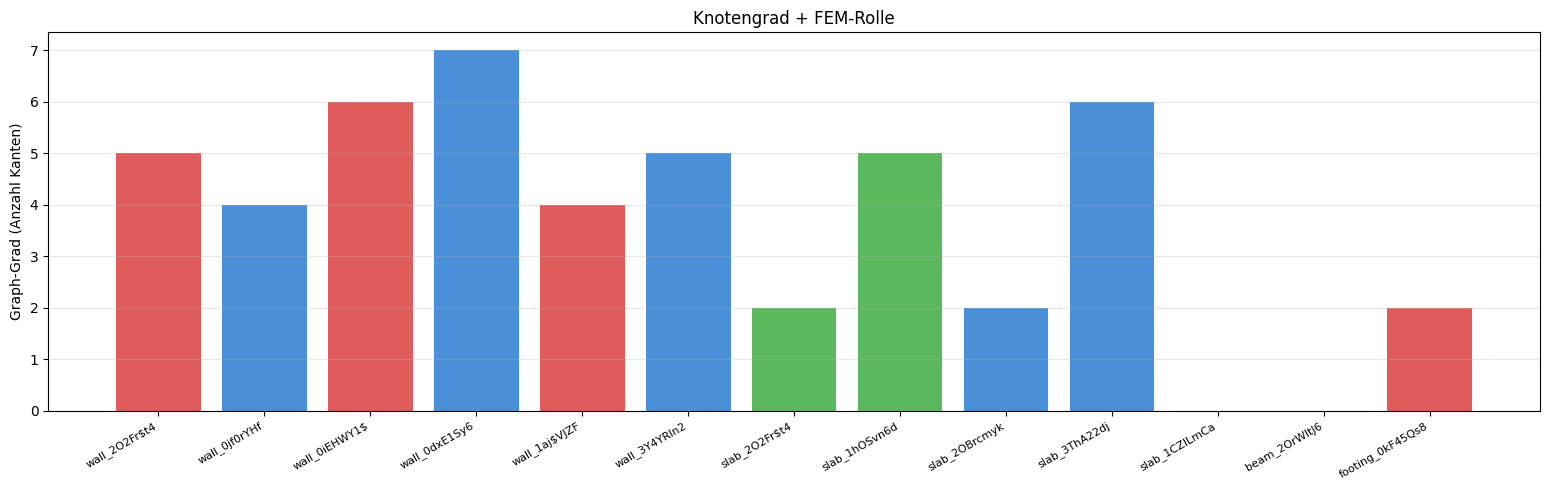

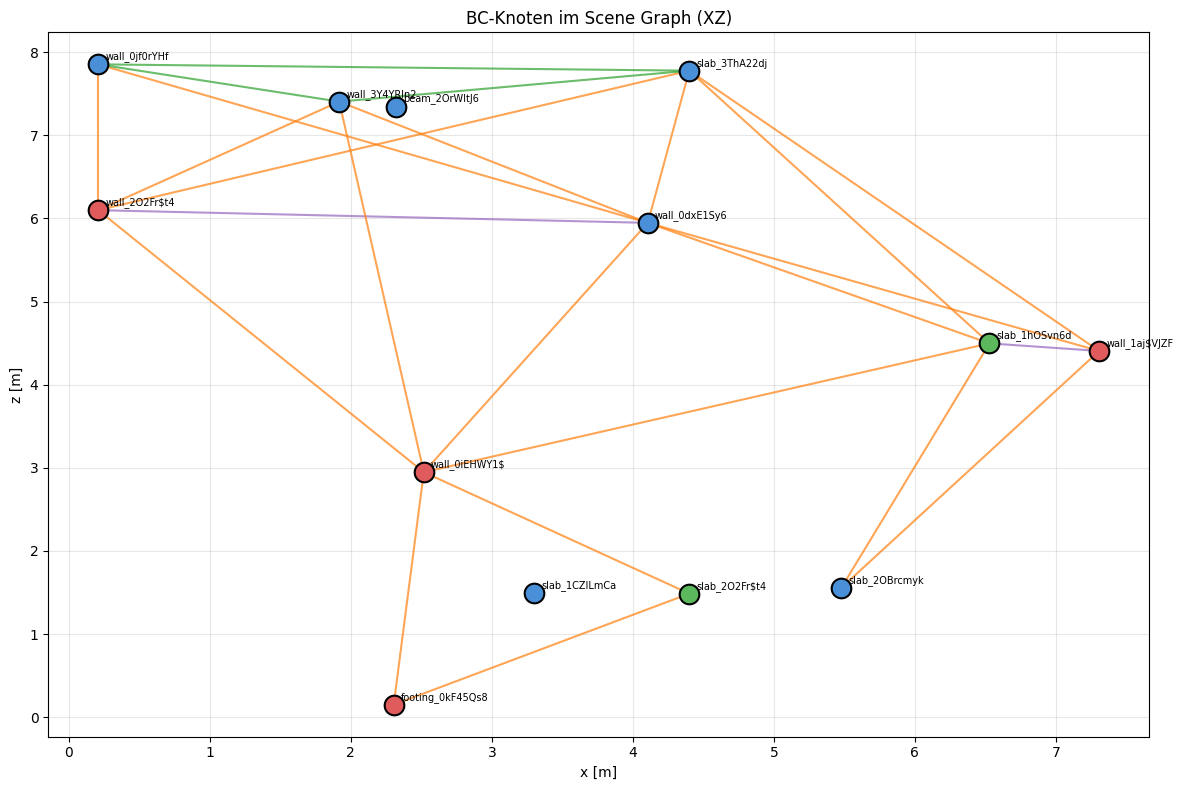

In [55]:
from matplotlib.patches import Patch

nodes_list = list(G.nodes)
degrees    = {n: sum(1 for e in G.edges if n in e) for n in nodes_list}
bar_colors = []
for n in nodes_list:
    if n in sg_info['foundation_nodes']:   bar_colors.append('#e05c5c')
    elif n in sg_info['load_surface_nodes']: bar_colors.append('#5cb85c')
    else:                                    bar_colors.append('#4a90d9')

fig, ax1 = plt.subplots(figsize=(max(10, len(nodes_list)*1.2), 5))
xp = onp.arange(len(nodes_list))
ax1.bar(xp, [degrees[n] for n in nodes_list], color=bar_colors)
ax1.set_xticks(xp); ax1.set_xticklabels(nodes_list, fontsize=8, rotation=30, ha='right')
ax1.set_ylabel('Graph-Grad (Anzahl Kanten)')
ax1.set_title('Knotengrad + FEM-Rolle', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

fig, ax2 = plt.subplots(figsize=(12, 8))
for key, obj in objects.items():
    col = '#e05c5c' if key in sg_info['foundation_nodes'] else           '#5cb85c' if key in sg_info['load_surface_nodes'] else '#4a90d9'
    cx, cz = obj['centroid'][0], obj['centroid'][2]
    ax2.scatter(cx, cz, s=200, c=col, zorder=4, edgecolors='black', lw=1.5)
    ax2.text(cx + 0.05, cz + 0.06, key, fontsize=7, zorder=5)
for o1, o2, rel in relationships:
    if o1 not in objects or o2 not in objects: continue
    x1, z1 = objects[o1]['centroid'][0], objects[o1]['centroid'][2]
    x2, z2 = objects[o2]['centroid'][0], objects[o2]['centroid'][2]
    ax2.plot([x1,x2],[z1,z2], color=EDGE_COLORS.get(rel,'#888'), lw=1.5, alpha=0.7)
ax2.set_xlabel('x [m]'); ax2.set_ylabel('z [m]')
ax2.set_title('BC-Knoten im Scene Graph (XZ)', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 12 — Material-Mapping aus Scene Graph

Jeder Graphknoten liefert bereits E + ν aus dem IFC-Parsing (Schritt 3).  
Hier werden die Werte verifiziert und der effektive E-Modul für den Solver berechnet.

In [56]:
print(f'{"Knoten":18s}  {"Label":8s}  {"E [kN/m²]":>12s}  '
      f'{"ν":>6s}  Quelle')
print('-' * 60)

vol_sum  = 0.0
E_vol    = 0.0
nu_vol   = 0.0

for node, data in G.nodes(data=True):
    E_val = data['E_kNm2']
    nu_v  = data['nu']
    vol   = data['volume']
    src   = 'IFC' if E_val != E_DEFAULT else 'Fallback'
    print(f'  {node:16s}  {data["semantic_label"]:8s}  '
          f'{E_val:>12.0f}  {nu_v:>6.2f}  {src}')
    vol_sum += vol; E_vol += E_val * vol; nu_vol += nu_v * vol

E_eff  = E_vol  / vol_sum if vol_sum > 0 else E_DEFAULT
nu_eff = nu_vol / vol_sum if vol_sum > 0 else NU_DEFAULT
mu_eff    = E_eff / (2.0 * (1.0 + nu_eff))
lmbda_eff = E_eff * nu_eff / ((1.0 + nu_eff) * (1.0 - 2.0 * nu_eff))

print(f'\nVol.-gewichteter E_eff = {E_eff:.0f} kN/m²  '
      f'ν_eff = {nu_eff:.3f}')
print(f'μ = {mu_eff:.1f}  λ = {lmbda_eff:.1f}  (kN/m²)')

Knoten              Label        E [kN/m²]       ν  Quelle
------------------------------------------------------------
  wall_2O2Fr$t4     wall          30000000    0.20  Fallback
  wall_0jf0rYHf     wall          30000000    0.20  Fallback
  wall_0iEHWY1$     wall          30000000    0.20  Fallback
  wall_0dxE1Sy6     wall          30000000    0.20  Fallback
  wall_1aj$VJZF     wall          30000000    0.20  Fallback
  wall_3Y4YRln2     wall          30000000    0.20  Fallback
  slab_2O2Fr$t4     slab          30000000    0.20  Fallback
  slab_1hOSvn6d     slab          30000000    0.20  Fallback
  slab_2OBrcmyk     slab          30000000    0.20  Fallback
  slab_3ThA22dj     slab          30000000    0.20  Fallback
  slab_1CZILmCa     slab          30000000    0.20  Fallback
  beam_2OrWItJ6     beam          30000000    0.20  Fallback
  footing_0kF45Qs8  footing       30000000    0.20  Fallback

Vol.-gewichteter E_eff = 30000000 kN/m²  ν_eff = 0.200
μ = 12500000.0  λ = 8333333.3  

### Visualisierung: E-Modul + Volumenanteil

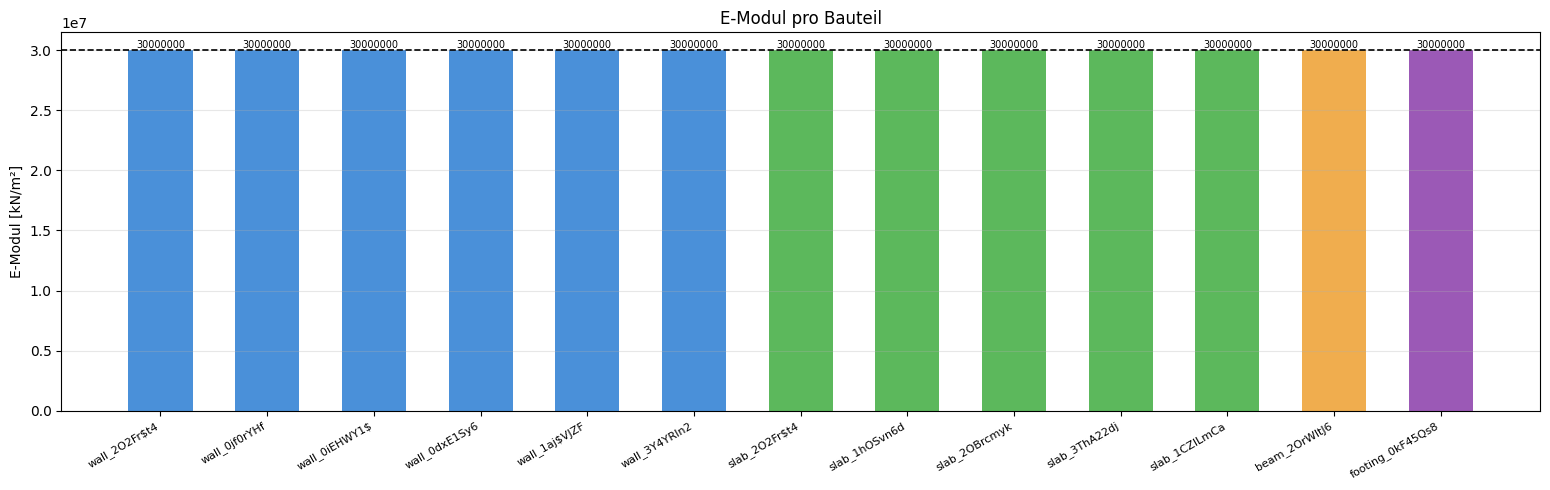

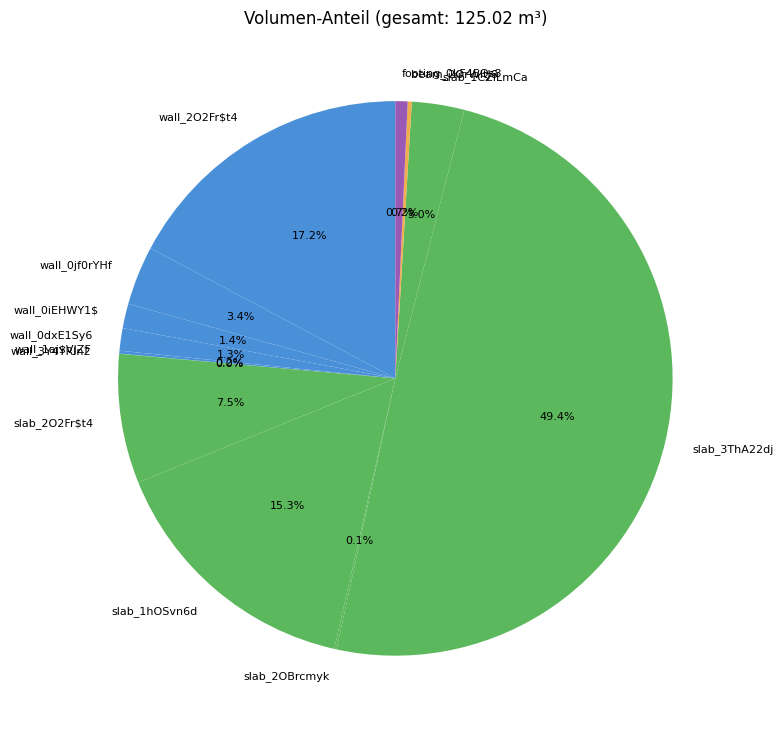

In [57]:
nodes_m = list(G.nodes)
E_vals  = [G.nodes[n]['E_kNm2']  for n in nodes_m]
nu_vals = [G.nodes[n]['nu']      for n in nodes_m]
vols    = [G.nodes[n]['volume']  for n in nodes_m]
cols_m  = [COLOR_MAP.get(G.nodes[n]['semantic_label'], '#aaa') for n in nodes_m]

fig, ax1 = plt.subplots(figsize=(max(10, len(nodes_m)*1.2), 5))
x_pos = onp.arange(len(nodes_m))
bars  = ax1.bar(x_pos, E_vals, color=cols_m, width=0.6)
ax1.axhline(E_eff, color='black', ls='--', lw=1.2)
ax1.set_xticks(x_pos); ax1.set_xticklabels(nodes_m, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('E-Modul [kN/m²]'); ax1.set_title('E-Modul pro Bauteil', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, E_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 100, f'{val:.0f}',
             ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

fig, ax2 = plt.subplots(figsize=(8, 8))
ax2.pie(vols, labels=nodes_m, colors=cols_m, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 8})
ax2.set_title(f'Volumen-Anteil (gesamt: {sum(vols):.2f} m³)', fontsize=12)
plt.tight_layout(); plt.show()


## 13 — GMSH Tet4-Volumennetz aus IFC-Geometrie

Strategie: Die **echte IFC-Dreiecksgeometrie** (via `ifcopenshell.geom`) wird als
GMSH-STL-Basis eingelesen. Für jedes Bauteil wird die Oberfläche zu einem
Volumen geschlossen (`ClassifySurfaces` + `CreateGeometry`).
Anschließend verbindet `fragment()` alle Volumen an gemeinsamen Kontaktflächen
(Wand↔Decke, Stütze↔Decke → Knoten-Merge automatisch).

**Fallback:** Wenn `ClassifySurfaces` kein Volumen erzeugt (offene Geometrie), wird
eine BBox als Näherung verwendet — mit explizitem Hinweis.


In [59]:
def build_tet4_from_ifc(
    ifc_model, elements_raw: list, mesh_size: float, out_msh: str,
    z_global_min: float = 0.0,
) -> Tuple[int, int]:
    """
    Tet4-Netz aus IFC-Geometrie via STL-Merge:
    1. Pro Bauteil Dreiecke aus ifcopenshell.geom lesen
    2. Als STL-Datei speichern (struct.pack — kein numpy-stl nötig)
    3. gmsh.merge(stl) lädt die Oberfläche
    4. ClassifySurfaces + CreateGeometry → geschlossenes Volumen
    5. Alle Bauteile per fragment() verbinden (Knoten-Merge)
    6. Vernetzung mit max. mesh_size
    """
    import struct, tempfile, os

    if gmsh.isInitialized(): gmsh.finalize()
    gmsh.initialize()
    gmsh.option.setNumber('General.Terminal', 1)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMax', mesh_size)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMin', mesh_size * 0.2)
    gmsh.option.setNumber('Mesh.Algorithm3D', 4)
    gmsh.model.add('ifc_geom')

    geom_settings = ifcopenshell.geom.settings()
    geom_settings.set(geom_settings.USE_WORLD_COORDS, True)

    fallback_bbox = []   # BBoxen für Elemente ohne auflösbare Geometrie
    n_merged = 0

    for elem_data in elements_raw:
        # GUID → IFC-Element
        ifc_elem = None
        for ifc_class in list(IFC_LABEL_MAP.keys()):
            hits = [e for e in ifc_model.by_type(ifc_class)
                    if e.GlobalId == elem_data['guid']]
            if hits:
                ifc_elem = hits[0]; break
        if ifc_elem is None:
            fallback_bbox.append(elem_data); continue

        # ── Dreiecke aus IFC ──────────────────────────────────────
        try:
            shape = ifcopenshell.geom.create_shape(geom_settings, ifc_elem)
            verts = onp.array(shape.geometry.verts, dtype=float).reshape(-1, 3)
            faces = onp.array(shape.geometry.faces, dtype=int).reshape(-1, 3)
        except Exception as exc:
            print(f'  SKIP Geom {elem_data["name"]}: {exc}')
            fallback_bbox.append(elem_data); continue

        if len(faces) == 0:
            fallback_bbox.append(elem_data); continue

        # Z-Normalisierung
        verts[:, 2] -= z_global_min

        # ── STL binary schreiben (kein externes Paket nötig) ──────
        tmp = tempfile.NamedTemporaryFile(suffix='.stl', delete=False)
        tmp.write(b'\x00' * 80)                  # header
        tmp.write(struct.pack('<I', len(faces)))   # n_triangles
        for tri in faces:
            v0, v1, v2 = verts[tri[0]], verts[tri[1]], verts[tri[2]]
            e1, e2 = v1 - v0, v2 - v0
            normal = onp.cross(e1, e2)
            nlen = onp.linalg.norm(normal)
            if nlen > 0: normal /= nlen
            tmp.write(struct.pack('<3f', *normal))
            tmp.write(struct.pack('<3f', *v0))
            tmp.write(struct.pack('<3f', *v1))
            tmp.write(struct.pack('<3f', *v2))
            tmp.write(struct.pack('<H', 0))        # attribute byte count
        stl_path = tmp.name
        tmp.close()

        # ── In GMSH-Modell mergen ─────────────────────────────────
        gmsh.merge(stl_path)
        os.unlink(stl_path)
        n_merged += 1

    print(f'  {n_merged} Elemente als STL gemergt  ({len(fallback_bbox)} ohne Geom)')

    if n_merged == 0 and not fallback_bbox:
        raise RuntimeError('Keine IFC-Geometrie ladbar!')

    if n_merged > 0:
        # ── Oberflächen zu Volumen schließen ──────────────────────
        gmsh.model.mesh.classifySurfaces(
            onp.pi,   # angle: alle Flächen einer Komponente zusammenfassen
            True,     # boundary: Randkurven klassifizieren
            True,     # forReparametrization
            onp.pi,   # curveAngle
        )
        gmsh.model.mesh.createGeometry()

    # ── OCC-Fallback-BBoxen für Elemente ohne Geometrie ──────────
    if fallback_bbox:
        for elem_data in fallback_bbox:
            bmin = onp.array(elem_data['bbox_min'])
            bmax = onp.array(elem_data['bbox_max'])
            dims = bmax - bmin
            if onp.any(dims < 0.01): continue
            gmsh.model.occ.addBox(
                float(bmin[0]), float(bmin[1]), float(bmin[2]),
                float(dims[0]), float(dims[1]), float(dims[2]),
            )
            print(f'  BBox-Fallback: {elem_data["name"]}')
        gmsh.model.occ.synchronize()

    vols = gmsh.model.getEntities(3)
    print(f'  Volumen vor Fragment: {len(vols)}')

    # ── Fragment: Knoten-Merge aller Volumen ──────────────────────
    if len(vols) > 1:
        gmsh.model.occ.fragment(vols, [])
        gmsh.model.occ.synchronize()
        vols = gmsh.model.getEntities(3)

    print(f'  GMSH: {len(vols)} Volumen → Vernetzung ...')
    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(1)
    try: gmsh.model.mesh.optimize('Netgen')
    except Exception: pass
    gmsh.write(str(out_msh))
    n_nodes = len(gmsh.model.mesh.getNodes()[0])
    n_tets  = len(gmsh.model.mesh.getElementsByType(4)[0])
    gmsh.finalize()
    return n_nodes, n_tets


def build_tet4_from_bboxes(
    G: nx.DiGraph, mesh_size: float, out_msh: str
) -> Tuple[int, int]:
    """BBox-Netz mit korrektem OCC-Fragment-Merge."""
    if gmsh.isInitialized(): gmsh.finalize()
    gmsh.initialize()
    gmsh.option.setNumber('General.Terminal', 0)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMax', mesh_size)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMin', mesh_size * 0.2)
    gmsh.option.setNumber('Mesh.Algorithm3D', 4)
    gmsh.model.add('ifc_bboxes')

    vol_tags = []
    for node, data in G.nodes(data=True):
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        dims = bmax - bmin
        if onp.any(dims < 0.01): continue
        tag = gmsh.model.occ.addBox(
            float(bmin[0]), float(bmin[1]), float(bmin[2]),
            float(dims[0]), float(dims[1]), float(dims[2]),
        )
        vol_tags.append(tag)

    gmsh.model.occ.synchronize()

    if len(vol_tags) > 1:
        all_v = [(3, t) for t in vol_tags]
        gmsh.model.occ.fragment(all_v, [])
        gmsh.model.occ.synchronize()

    vols = gmsh.model.getEntities(3)
    print(f'  GMSH: {len(vols)} Volumen (BBox) → Vernetzung ...')
    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(1)
    try: gmsh.model.mesh.optimize('Netgen')
    except Exception: pass
    gmsh.write(str(out_msh))
    n_nodes = len(gmsh.model.mesh.getNodes()[0])
    n_tets  = len(gmsh.model.mesh.getElementsByType(4)[0])
    gmsh.finalize()
    return n_nodes, n_tets


# ── Hauptaufruf ───────────────────────────────────────────────────────
msh_path = DATA_DIR / 'msh' / 'ifc_scene_graph.msh'
print('Starte GMSH Tet4-Vernetzung ...')
USE_IFC_GEOM = True   # True = echte IFC-Dreiecke (STL-Merge); False = BBox

def _read_tets(path):
    raw = meshio.read(str(path))
    return raw, raw.points, raw.cells_dict.get('tetra', onp.array([]))

if USE_IFC_GEOM and not USE_DEMO_MODEL:
    try:
        n_nodes, n_tets = build_tet4_from_ifc(
            ifc_model, elements_raw, MESH_SIZE, msh_path,
            z_global_min=Z_GLOBAL_MIN,
        )
        raw, points_m, cells_m = _read_tets(msh_path)
        if len(cells_m) == 0:
            raise RuntimeError('IFC-Geom-Netz enthält keine Tet4 — kein geschlossenes Volumen')
        print(f'  IFC-Geom-Netz: {n_nodes} Knoten, {n_tets} Tet4  (DOF: {n_nodes*3})')
    except Exception as exc:
        print(f'  IFC-Geom fehlgeschlagen ({exc}) — Fallback BBox')
        n_nodes, n_tets = build_tet4_from_bboxes(G, MESH_SIZE, msh_path)
        raw, points_m, cells_m = _read_tets(msh_path)
        print(f'  BBox-Netz: {n_nodes} Knoten, {n_tets} Tet4  (DOF: {n_nodes*3})')
else:
    n_nodes, n_tets = build_tet4_from_bboxes(G, MESH_SIZE, msh_path)
    raw, points_m, cells_m = _read_tets(msh_path)
    print(f'  BBox-Netz: {n_nodes} Knoten, {n_tets} Tet4  (DOF: {n_nodes*3})')

if len(cells_m) == 0:
    raise RuntimeError('Keine Tet4-Elemente — auch BBox-Fallback fehlgeschlagen')

mesh     = Mesh(points_m, cells_m)
ele_type = 'TET4'
print(f'BBox: x [{points_m[:,0].min():.2f}, {points_m[:,0].max():.2f}]  '
      f'y [{points_m[:,1].min():.2f}, {points_m[:,1].max():.2f}]  '
      f'z [{points_m[:,2].min():.2f}, {points_m[:,2].max():.2f}]')

from scipy import sparse as _sp
from scipy.sparse.csgraph import connected_components as _cc
_n = len(points_m)
_r, _c = [], []
for _cell in cells_m:
    for _i in range(4):
        for _j in range(4):
            if _i != _j: _r.append(_cell[_i]); _c.append(_cell[_j])
_adj = _sp.csr_matrix((onp.ones(len(_r)), (_r, _c)), shape=(_n, _n))
_n_comp, _ = _cc(_adj, directed=False)
print(f'Verbundene Netz-Komponenten: {_n_comp}')
if _n_comp > 1:
    print(f'  → Warnung: {_n_comp} unverbundene Teilnetze!')
    print('  → Tipp: USE_IFC_GEOM=False (BBox-Netz), oder MESH_SIZE erhöhen.')
else:
    print('  → Netz vollständig verbunden — Solver kann durchlaufen.')


Starte GMSH Tet4-Vernetzung ...
Info    : Reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmpw3bamjce.stl'...
Info    : Mesh is in binary format
Info    : 76 facets in solid 0 
Info    : Done reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmpw3bamjce.stl'
Info    : Reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmpvpw3gsh7.stl'...
Info    : Mesh is in binary format
Info    : 12 facets in solid 0 
Info    : Done reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmpvpw3gsh7.stl'
Info    : Reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmp44cjz8q3.stl'...
Info    : Mesh is in binary format
Info    : 12 facets in solid 0 
Info    : Done reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmp44cjz8q3.stl'
Info    : Reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmpfmwn2luz.stl'...
Info    : Mesh is in binary format
Info    : 12 facets in solid 0 
Info    : Done reading '/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/tmpfm

Info    : [ 10%] Meshing surface 151 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 151 (Discrete surface, MeshAdapt)
Info    : [ 10%] Meshing surface 152 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 153 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 154 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 155 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 155 (Discrete surface, MeshAdapt)
Info    : [ 10%] Meshing surface 156 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 156 (Discrete surface, MeshAdapt)
Info    : [ 10%] Meshing surface 157 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 158 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 158 (Discrete surface, MeshAdapt)
Info    : [ 10%] Meshing surface 159 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 159 (Discrete surface, MeshAdapt)

Info    : [ 10%] Meshing surface 187 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 187 (Discrete surface, MeshAdapt)
Info    : [ 10%] Meshing surface 188 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 188 (Discrete surface, MeshAdapt)
Info    : [ 10%] Meshing surface 189 (Discrete surface, Frontal-Delaunay)
Info    : [ 10%] Meshing surface 189 (Discrete surface, MeshAdapt)
Info    : [ 20%] Meshing surface 190 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 190 (Discrete surface, MeshAdapt)
Info    : [ 20%] Meshing surface 191 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Triangle not found for first derivative at uv=(-0.746494,0.193466) on discrete surface 191
Info    : [ 20%] Triangle not found for first derivative at uv=(0.746494,-0.193466) on discrete surface 191
Info    : [ 20%] Meshing surface 192 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 192 (Discrete surface, MeshAdapt)
Info 

Info    : [ 20%] Meshing surface 195 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 195 (Discrete surface, MeshAdapt)
Info    : [ 20%] Meshing surface 196 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 197 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 198 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 199 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 200 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 200 (Discrete surface, MeshAdapt)
Info    : [ 20%] Meshing surface 201 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 201 (Discrete surface, MeshAdapt)
Info    : [ 20%] Meshing surface 202 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 203 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 204 (Discrete surface, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 205 (Discrete surface, Fro

Info    : [ 30%] Meshing surface 230 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 231 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 232 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 233 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 234 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 235 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 236 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 237 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 237 (Discrete surface, MeshAdapt)
Info    : [ 30%] Meshing surface 238 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 239 (Discrete surface, Frontal-Delaunay)
Info    : [ 30%] :-( There are 3 intersections in the 1D mesh (curves 512 511 512)
Info    : [ 30%] 8-| Splitting those edges and trying again - level 0
Info    : [ 30%] :-) All edges recovered

...

Info    : [ 80%] Meshing surface 463 (Discrete surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 463 (Discrete surface, MeshAdapt)
Info    : [ 80%] Meshing surface 464 (Discrete surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 464 (Discrete surface, MeshAdapt)
Info    : [ 80%] Meshing surface 465 (Discrete surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 465 (Discrete surface, MeshAdapt)
Info    : [ 80%] Meshing surface 466 (Discrete surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 466 (Discrete surface, MeshAdapt)
Info    : [ 80%] Meshing surface 467 (Discrete surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 467 (Discrete surface, MeshAdapt)
Info    : [ 80%] Meshing surface 468 (Discrete surface, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 468 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 469 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 470 (Discrete surface, Frontal-Delaunay)
Info  

Info    : [ 90%] Meshing surface 478 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 478 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 479 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 479 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 480 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 480 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 481 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 481 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 482 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 482 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 483 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 484 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 484 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 485 (Discrete surface, Frontal-Delaunay)
Info  

Info    : [ 90%] Meshing surface 493 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 493 (Discrete surface, MeshAdapt)


Info    : [ 90%] Meshing surface 494 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Triangle not found for first derivative at uv=(0.571638,0.278292) on discrete surface 494
Info    : [ 90%] Meshing surface 494 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 495 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 495 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 496 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 496 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 497 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 497 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 498 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 498 (Discrete surface, MeshAdapt)
Info    : [ 90%] Meshing surface 499 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 500 (Discrete surface, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 500 (Di

RuntimeError: Keine Tet4-Elemente — GMSH-Fehler

### Visualisierung: Netz-Querschnitte

In [ ]:
tet_centroids = points_m[cells_m].mean(axis=1)
y_mid = (points_m[:,1].min() + points_m[:,1].max()) / 2.0
y_tol = (points_m[:,1].max() - points_m[:,1].min()) / 5.0
mask_xz = onp.abs(tet_centroids[:,1] - y_mid) < y_tol
x_mid = (points_m[:,0].min() + points_m[:,0].max()) / 2.0
x_tol = (points_m[:,0].max() - points_m[:,0].min()) / 5.0
mask_yz = onp.abs(tet_centroids[:,0] - x_mid) < x_tol
z_slab = points_m[:,2].max()
mask_xy = onp.abs(tet_centroids[:,2] - z_slab + MESH_SIZE/2) < MESH_SIZE

for mask, x_col, z_col, xlabel, ylabel, color, title in [
    (mask_xz, 0, 2, 'x [m]', 'z [m]', '#4a90d9', f'XZ-Schnitt — {mask_xz.sum()} Elemente'),
    (mask_yz, 1, 2, 'y [m]', 'z [m]', '#e05c5c', f'YZ-Schnitt — {mask_yz.sum()} Elemente'),
    (mask_xy, 0, 1, 'x [m]', 'y [m]', '#5cb85c', f'XY-Draufsicht Decke — {mask_xy.sum()} Elemente'),
]:
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(tet_centroids[mask, x_col], tet_centroids[mask, z_col],
               s=1, c=color, alpha=0.4)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12); ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()


## 14 — Randbedingungen aus Scene Graph

Die Graphanalyse (Schritt 11) liefert automatisch:
- `foundation_nodes` → Einspannung am Fuß
- `load_surface_nodes` → Lastfläche oben

In [ ]:
z_min = float(points_m[:, 2].min())
z_top = float(points_m[:, 2].max())
x_min = float(points_m[:, 0].min())
x_max = float(points_m[:, 0].max())
tol_bc = MESH_SIZE / 4.0

# Eigengewicht → Flächenlast auf Deckenoberkante
EG_kN = sum(
    GAMMA_BETON * d['volume']
    for _, d in G.nodes(data=True)
)
A_plan = (x_max - x_min) * (points_m[:,1].max() - points_m[:,1].min())
q_load = EG_kN / A_plan + Q_NUTZLAST

print(f'Eigengewicht   : {EG_kN:.1f} kN')
print(f'Grundrissfläche: {A_plan:.1f} m²')
print(f'Gesamtlast     : {q_load:.2f} kN/m²  (EG + {Q_NUTZLAST} kN/m² Nutzlast)')
print(f'z_min={z_min:.3f}   z_top={z_top:.3f}   tol_bc={tol_bc:.4f} m')

def zero(p): return 0.0

# Einspannung Fundamentebene
def at_base(p): return jnp.isclose(p[2], z_min, atol=tol_bc)

# Horizontale Stabilisierung (Symmetrielager x)
def at_x0(p): return jnp.isclose(p[0], x_min, atol=tol_bc)
def at_xL(p): return jnp.isclose(p[0], x_max, atol=tol_bc)

# Lastfläche oben (aus Graphanalyse: load_surface_nodes)
def at_top(p): return jnp.isclose(p[2], z_top, atol=tol_bc)

dirichlet_bc_info = [
    [at_base, at_base, at_base, at_x0, at_xL],
    [0,       1,       2,       0,     0    ],
    [zero,    zero,    zero,    zero,  zero ],
]
location_fns = [at_top]

n_base = int(onp.sum(onp.abs(points_m[:,2] - z_min) < tol_bc))
n_top  = int(onp.sum(onp.abs(points_m[:,2] - z_top) < tol_bc))
print(f'\nEinspannung z=0     : {n_base} Knoten')
print(f'Lastfläche z=z_top  : {n_top} Knoten')
print(f'Graph → Einspannung : {sg_info["foundation_nodes"]}')
print(f'Graph → Lastfläche  : {sg_info["load_surface_nodes"]}')

### Visualisierung: Randbedingungen im Netz

In [ ]:
_mask_base  = onp.abs(points_m[:,2] - z_min) < tol_bc
_mask_top   = onp.abs(points_m[:,2] - z_top) < tol_bc
_mask_x0    = onp.abs(points_m[:,0] - x_min) < tol_bc
_mask_xL    = onp.abs(points_m[:,0] - x_max) < tol_bc
_mask_free  = ~(_mask_base | _mask_top | _mask_x0 | _mask_xL)

for x_col, z_col, xlabel, title in [
    (0, 2, 'x [m]', 'XZ — Randbedingungen'),
    (1, 2, 'y [m]', 'YZ — Randbedingungen'),
]:
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(points_m[_mask_free,  x_col], points_m[_mask_free,  z_col], s=1, c='#cccccc', alpha=0.3)
    ax.scatter(points_m[_mask_base,  x_col], points_m[_mask_base,  z_col], s=4, c='#e05c5c', alpha=0.8)
    ax.scatter(points_m[_mask_top,   x_col], points_m[_mask_top,   z_col], s=4, c='#5cb85c', alpha=0.8)
    ax.scatter(points_m[_mask_x0,    x_col], points_m[_mask_x0,    z_col], s=4, c='#f0ad4e', alpha=0.8)
    ax.scatter(points_m[_mask_xL,    x_col], points_m[_mask_xL,    z_col], s=4, c='#f0ad4e', alpha=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel('z [m]')
    ax.set_title(title, fontsize=12); ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()


## 15 — JaxFEM-Solver (lineare 3D-Elastizität)

In [ ]:
mu    = mu_eff
lmbda = lmbda_eff
q     = q_load


class IFC_SG_FEM(Problem):
    """Lineare 3D-Elastizität — IFC Scene Graph."""

    def get_tensor_map(self):
        def stress(u_grad):
            eps = 0.5 * (u_grad + u_grad.T)
            return lmbda * jnp.trace(eps) * jnp.eye(self.dim) + 2.0 * mu * eps
        return stress

    def get_surface_maps(self):
        def load_top(u, x):
            return jnp.array([0.0, 0.0, q])
        return [load_top]


problem = IFC_SG_FEM(
    mesh=mesh, vec=3, dim=3, ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)

print(f'Problem : {len(cells_m)} Tet4, {len(points_m)*3} DOF')
print(f'E_eff   : {E_eff:.0f} kN/m²   ν_eff: {nu_eff:.3f}')
print(f'Last q  : {q:.2f} kN/m²')
print('Löse (UMFPACK) ...')

sol   = solver(problem, solver_options={'umfpack_solver': {}})
ux    = onp.array(sol[0][:, 0])
uy    = onp.array(sol[0][:, 1])
uz    = onp.array(sol[0][:, 2])
u_abs = onp.sqrt(ux**2 + uy**2 + uz**2)

print(f'\nu_z_max (Absenkung) : {uz.min()*1000:.3f} mm')
print(f'|u|_max              : {u_abs.max()*1000:.3f} mm')
assert uz.min() < 0, 'Keine Absenkung — Lastvorzeichen prüfen!'

## 16 — Spannungsberechnung (Tet4)

In [ ]:
def compute_stress_tet4(
    pts: onp.ndarray, cells: onp.ndarray,
    u_sol: onp.ndarray, lmbda: float, mu: float,
) -> onp.ndarray:
    sigma_gp, gp_coords = [], []
    for cell in cells:
        p  = pts[cell]
        ue = u_sol[cell]
        J  = p[1:4] - p[0]
        try: J_inv = onp.linalg.inv(J.T)
        except onp.linalg.LinAlgError: continue
        dN   = onp.array([[-1,-1,-1],[1,0,0],[0,1,0],[0,0,1]], dtype=float)
        dNdx = dN @ J_inv
        grad_u = ue.T @ dNdx
        eps    = 0.5 * (grad_u + grad_u.T)
        sig    = lmbda * onp.trace(eps) * onp.eye(3) + 2.0 * mu * eps
        sigma_gp.append([sig[0,0],sig[1,1],sig[2,2],
                         sig[0,1],sig[0,2],sig[1,2]])
        gp_coords.append(p.mean(axis=0))
    sigma_gp  = onp.array(sigma_gp)
    gp_coords = onp.array(gp_coords)
    _, idx = cKDTree(gp_coords).query(pts)
    return sigma_gp[idx]


sigma = compute_stress_tet4(points_m, cells_m,
                             onp.array(sol[0]), float(lmbda), float(mu))
s11, s22, s33 = sigma[:,0], sigma[:,1], sigma[:,2]
s12, s13, s23 = sigma[:,3], sigma[:,4], sigma[:,5]
s_vm = onp.sqrt(0.5 * ((s11-s22)**2 + (s22-s33)**2 + (s33-s11)**2
                       + 6*(s12**2 + s13**2 + s23**2)))

print(f'σ_33  : {s33.min():.1f} … {s33.max():.1f} kN/m²')
print(f'σ_vM max: {s_vm.max():.1f} kN/m²  ({s_vm.max()/1000:.3f} MN/m²)')

### Visualisierung: Spannungs-Schnittbilder

In [ ]:
y_mid_pts = (points_m[:,1].min() + points_m[:,1].max()) / 2.0
y_tol_pts = (points_m[:,1].max() - points_m[:,1].min()) / 6.0
_xz = onp.abs(points_m[:,1] - y_mid_pts) < y_tol_pts
x_mid_pts = (points_m[:,0].min() + points_m[:,0].max()) / 2.0
x_tol_pts = (points_m[:,0].max() - points_m[:,0].min()) / 6.0
_yz = onp.abs(points_m[:,0] - x_mid_pts) < x_tol_pts
z_slab_pts = points_m[:,2].max()
_xy = onp.abs(points_m[:,2] - z_slab_pts) < tol_bc * 3

def _splot(pts, vals, xcol, zcol, xl, yl, cmap, title, sym=False):
    fig, ax = plt.subplots(figsize=(12, 8))
    vabs = onp.abs(vals).max()
    vmin = -vabs if sym else vals.min()
    vmax =  vabs if sym else vals.max()
    sc = ax.scatter(pts[:,xcol], pts[:,zcol], c=vals, cmap=cmap, s=2,
                    rasterized=True, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(title, fontsize=12); ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()

_splot(points_m[_xz], uz[_xz]*1000,  0, 2, 'x [m]', 'z [m]', 'RdBu',    'u_z [mm] — XZ',       sym=True)
_splot(points_m[_xz], s_vm[_xz],     0, 2, 'x [m]', 'z [m]', 'plasma',  'σ_vM [kN/m²] — XZ')
_splot(points_m[_xz], s33[_xz],      0, 2, 'x [m]', 'z [m]', 'RdBu_r',  'σ_zz [kN/m²] — XZ',  sym=True)
if _xy.sum() > 0:
    _splot(points_m[_xy], uz[_xy]*1000,    0, 1, 'x [m]', 'y [m]', 'RdBu',    'u_z [mm] — Decke',  sym=True)
    _splot(points_m[_xy], s_vm[_xy],       0, 1, 'x [m]', 'y [m]', 'plasma',  'σ_vM [kN/m²] — Decke')
    _splot(points_m[_xy], u_abs[_xy]*1000, 0, 1, 'x [m]', 'y [m]', 'viridis', '|u| [mm] — Decke')


## 17 — PyVista-Visualisierung

In [ ]:
pv.set_jupyter_backend('static')

cell_array = onp.hstack([
    onp.full((len(cells_m), 1), 4, dtype=onp.int64),
    cells_m.astype(onp.int64)
]).flatten()
cell_types = onp.full(len(cells_m), pv.CellType.TETRA)

grid = pv.UnstructuredGrid(cell_array, cell_types, points_m)
grid.point_data['uz_mm']    = uz * 1000
grid.point_data['u_abs_mm'] = u_abs * 1000
grid.point_data['sigma_vm'] = s_vm
grid.point_data['sigma_zz'] = s33

max_uz   = max(abs(uz.min()), abs(uz.max()))
char_len = float(points_m[:,2].max() - points_m[:,2].min())
warp_fac = max(round(min(0.05 * char_len / max(max_uz, 1e-12), 500.0)), 1)
print(f'Warpfaktor: ×{warp_fac}')

disp_vec = onp.column_stack([ux, uy, uz])
grid.point_data['displacement'] = disp_vec
warped = grid.warp_by_vector('displacement', factor=warp_fac)
warped.point_data['sigma_vm'] = s_vm
warped.point_data['uz_mm']    = uz * 1000

cam_pos = [(12, -8, 8), (2, 2, 1.5), (0, 0, 1)]

plotter = pv.Plotter(shape=(2, 2), window_size=(1200, 800), off_screen=True)
plotter.set_background('white')
for row, col, field, title, cmap in [
    (0, 0, 'uz_mm',    'u_z [mm]',     'RdBu'),
    (0, 1, 'u_abs_mm', '|u| [mm]',     'viridis'),
    (1, 0, 'sigma_vm', 'σ_vM [kN/m²]', 'plasma'),
    (1, 1, 'sigma_zz', 'σ_zz [kN/m²]', 'RdBu_r'),
]:
    plotter.subplot(row, col)
    plotter.add_mesh(grid, scalars=field, cmap=cmap, show_edges=False,
                     opacity=0.93, scalar_bar_args={'title': title})
    plotter.add_title(title, font_size=10)
    plotter.camera_position = cam_pos
    plotter.add_axes()
plotter.show(title=f'IFC → Scene Graph → JaxFEM  |  {len(cells_m)} Tet4')

# Warp-Plot
plotter2 = pv.Plotter(shape=(1, 2), window_size=(1200, 500), off_screen=True)
plotter2.set_background('white')
plotter2.subplot(0, 0)
plotter2.add_mesh(grid,   scalars='u_abs_mm', cmap='viridis', opacity=0.3, show_edges=False,
                  scalar_bar_args={'title': '|u| [mm] (unverformt)'})
plotter2.add_mesh(warped, scalars='uz_mm',    cmap='RdBu',    opacity=0.9, show_edges=False,
                  scalar_bar_args={'title': f'u_z [mm] (×{warp_fac})'})
plotter2.add_title(f'Verformte Geometrie (×{warp_fac})', font_size=10)
plotter2.camera_position = cam_pos; plotter2.add_axes()
plotter2.subplot(0, 1)
plotter2.add_mesh(warped, scalars='sigma_vm', cmap='plasma', opacity=0.95, show_edges=False,
                  scalar_bar_args={'title': 'σ_vM [kN/m²]'})
plotter2.add_title(f'von-Mises (verformt ×{warp_fac})', font_size=10)
plotter2.camera_position = cam_pos; plotter2.add_axes()
plotter2.show()

vtu_path = str(DATA_DIR / 'vtk' / 'ifc_sg_fem.vtu')
save_sol(problem.fes[0], sol[0], vtu_path)
print('VTK gespeichert:', vtu_path)

## 18 — FEM-Ergebnisse in Scene Graph zurückschreiben

Analog Poux & Lehtola (2025), Step 12:  
Jeder Knoten erhält `uz_min_mm`, `u_abs_max_mm`, `sigma_vm_max` aus dem FEM-Solver.

In [ ]:
def write_fem_to_graph(
    G: nx.DiGraph, points_m, uz, u_abs, s_vm
) -> nx.DiGraph:
    for node, data in G.nodes(data=True):
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        tol  = 1e-6
        mask = (
            (points_m[:,0] >= bmin[0]-tol) & (points_m[:,0] <= bmax[0]+tol) &
            (points_m[:,1] >= bmin[1]-tol) & (points_m[:,1] <= bmax[1]+tol) &
            (points_m[:,2] >= bmin[2]-tol) & (points_m[:,2] <= bmax[2]+tol)
        )
        if not mask.any():
            continue
        G.nodes[node]['uz_min_mm']    = round(float(uz[mask].min() * 1000), 3)
        G.nodes[node]['u_abs_max_mm'] = round(float(u_abs[mask].max() * 1000), 3)
        G.nodes[node]['sigma_vm_max'] = round(float(s_vm[mask].max()), 1)
    return G


G = write_fem_to_graph(G, points_m, uz, u_abs, s_vm)

print(f'{"Knoten":18s}  {"Label":8s}  '
      f'{"uz_min [mm]":>12s}  {"u_abs [mm]":>10s}  {"σ_vM_max":>10s}')
print('-' * 68)
for node, data in G.nodes(data=True):
    print(f'  {node:16s}  {data["semantic_label"]:8s}  '
          f'{data.get("uz_min_mm", 0.0):>12.3f}  '
          f'{data.get("u_abs_max_mm", 0.0):>10.3f}  '
          f'{data.get("sigma_vm_max", 0.0):>10.1f}')

# JSON-Export (Scene Graph + FEM-Ergebnisse)
sg_json = {
    'meta': {
        'description' : 'IFC Scene Graph FEM',
        'ifc_path'    : ifc_path,
        'mesh_size'   : MESH_SIZE,
        'n_elements'  : int(len(cells_m)),
        'n_nodes_fem' : int(len(points_m)),
        'E_eff_kNm2'  : round(float(E_eff), 1),
        'nu_eff'      : round(float(nu_eff), 4),
        'q_kNm2'      : round(float(q), 2),
        'units'       : 'kN + m',
    },
    'nodes': {
        node: {k: v for k, v in data.items() if not isinstance(v, onp.ndarray)}
        for node, data in G.nodes(data=True)
    },
    'edges': [
        {'from': u, 'to': v, 'relationship': d['relationship'],
         'source': d.get('source', 'geometric')}
        for u, v, d in G.edges(data=True)
    ],
}
json_path = DATA_DIR / 'ifc_scene_graph_fem.json'
with open(json_path, 'w', encoding='utf-8') as fh:
    json.dump(sg_json, fh, indent=2, ensure_ascii=False, default=str)
print(f'\nJSON gespeichert: {json_path}')

### Visualisierung: Bauteil-Vergleich + Graph-Heatmap

In [ ]:
nodes_r  = list(G.nodes)
cols_r   = [COLOR_MAP.get(G.nodes[n]['semantic_label'], '#aaa') for n in nodes_r]
uz_vals  = [G.nodes[n].get('uz_min_mm',    0.0) for n in nodes_r]
ua_vals  = [G.nodes[n].get('u_abs_max_mm', 0.0) for n in nodes_r]
sv_vals  = [G.nodes[n].get('sigma_vm_max', 0.0) for n in nodes_r]

for vals, ylabel, title in [
    (uz_vals, 'u_z_min [mm]',    'Maximale Absenkung'),
    (ua_vals, '|u|_max [mm]',    'Maximale Verformung'),
    (sv_vals, 'σ_vM_max [kN/m²]','Max. von-Mises-Spannung'),
]:
    fig, ax = plt.subplots(figsize=(max(10, len(nodes_r)*1.2), 5))
    xp = onp.arange(len(nodes_r))
    bars = ax.bar(xp, vals, color=cols_r, width=0.6)
    ax.set_xticks(xp)
    ax.set_xticklabels([f'{n}' for n in nodes_r], fontsize=8, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(max(vals, key=abs)) * 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout(); plt.show()

import matplotlib.cm as cm
for attr, label, cmap_name, pos, pos_title in [
    ('sigma_vm_max', 'σ_vM_max [kN/m²]', 'plasma',  pos_xy, 'Scene Graph — σ_vM Heatmap (XY)'),
    ('uz_min_mm',   'u_z_min [mm]',      'RdBu_r',  pos_sp, 'Scene Graph — u_z Heatmap (Federlayout)'),
]:
    fig, ax = plt.subplots(figsize=(14, 10))
    vals_h = onp.array([G.nodes[n].get(attr, 0.0) for n in nodes_r])
    norm_h = plt.Normalize(vmin=vals_h.min(), vmax=vals_h.max())
    cmap_h = cm.get_cmap(cmap_name)
    for ni, node in enumerate(nodes_r):
        x, y = pos[node]
        ax.scatter(x, y, s=1200, c=[cmap_h(norm_h(vals_h[ni]))], zorder=3, edgecolors='black', lw=1)
        ax.text(x, y, f'{node}\n{vals_h[ni]:.1f}', ha='center', va='center', fontsize=6, zorder=4)
    for o1, o2, ed in G.edges(data=True):
        x1, y1 = pos[o1]; x2, y2 = pos[o2]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='-|>', color='#555', lw=1.5, mutation_scale=15), zorder=2)
    sm = plt.cm.ScalarMappable(cmap=cmap_h, norm=norm_h)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.7, label=label)
    ax.set_title(pos_title, fontsize=12); ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()


## 19 — LLM-Prompt aus angereichertem Scene Graph

Der vollständige Graph (IFC-Relationships + Spatial + FEM-Ergebnisse)  
wird in einen strukturierten Textprompt für Spatial-AI-Abfragen umgewandelt.

In [ ]:
def graph_to_llm_prompt(G: nx.DiGraph, uz, u_abs, s_vm, q) -> str:
    lines = [
        '=== IFC TRAGWERK — SCENE GRAPH + FEM-ERGEBNISSE ===',
        '',
        'BAUTEILE (Knoten):',
    ]
    for node, data in G.nodes(data=True):
        c = data.get('centroid', [0, 0, 0])
        lines.append(
            f'  [{node}]'
            f'  IFC={data.get("ifc_name", "?")} ({data.get("ifc_class","?")})'
            f'  Typ={data["semantic_label"]}'
            f'  Schwerpunkt=({c[0]:.1f}, {c[1]:.1f}, {c[2]:.1f}) m'
            f'  Volumen={data.get("volume", 0):.3f} m³'
            f'  E={data.get("E_kNm2", 0):.0f} kN/m²'
            f'  uz_min={data.get("uz_min_mm", 0):.3f} mm'
            f'  σ_vM_max={data.get("sigma_vm_max", 0):.1f} kN/m²'
        )
    lines += ['', 'BEZIEHUNGEN (Kanten):']
    for u_n, v_n, ed in G.edges(data=True):
        src = ed.get('source', 'geo')
        lines.append(f'  {u_n}  --[{ed["relationship"]} | {src}]-->  {v_n}')
    lines += [
        '',
        'FEM-ERGEBNISSE (Global):',
        f'  Max. Absenkung   : {uz.min()*1000:.3f} mm',
        f'  Max. Verformung  : {u_abs.max()*1000:.3f} mm',
        f'  Max. σ_vM        : {s_vm.max():.1f} kN/m²',
        f'  Gesamtlast       : {q:.2f} kN/m²',
        '',
        '==================================================',
    ]
    return '\n'.join(lines)


prompt = graph_to_llm_prompt(G, uz, u_abs, s_vm, q)
print(prompt)

# Beispiel-Fragen für Spatial AI
example_questions = [
    'Welches Bauteil ist strukturell am stärksten beansprucht?',
    'Wo liegt das Rissrisiko am höchsten (σ_vM)?',
    'Welche Bauteile sind direkt über der Stütze und tragen deren Last?',
    'Welche IFC-Relationships wurden automatisch erkannt?',
]

print('\n--- Beispiel-Abfragen für Spatial AI ---')
for q_example in example_questions:
    print(f'  → {q_example}')

print(f'\nLLM-Prompt bereit ({len(prompt)} Zeichen)')
print('  → client.messages.create(model="claude-sonnet-4-6", '
      'messages=[{"role":"user","content":prompt + "\\n\\nFRAGE: " + question}])')

## 20 — Zusammenfassung

| Schritt | Methode | Ergebnis |
|---------|---------|----------|
| 2 | IFC laden (Demo / eigene Datei) | IfcOpenShell, `Pset_MaterialMechanical` |
| 3 | Bauteil-Parsing + BBox + Material | `elements_raw` mit E, ν, BBox |
| 4 | Punktwolken-Visualisierung | XZ + YZ Schnittbilder |
| 5 | IFC-Relationship-Analyse | IfcRelAggregates, IfcRelAssociatesMaterial |
| 6 | Semantisches DBSCAN-Clustering | Objekt-Instanzen → IFC-Snap |
| 7 | Feature-Extraktion | Volumen, Höhe, Kompaktheit, Aspektverhältnis |
| 8 | Räumliche Beziehungsanalyse | above, adjacent, near |
| 9 | NetworkX DiGraph | Scene Graph (IFC + geometrisch) |
| 10 | Graph-Visualisierung | XY-Grundriss + Federlayout |
| 11 | Graph-Analyse | Randbedingungen + Lastflächen |
| 12 | Material-Mapping | E, ν aus IFC pro Knoten |
| 13 | GMSH Tet4-Netz | Aus BBox der Graphknoten |
| 14 | Randbedingungen | Aus Graphtopologie abgeleitet |
| 15 | JaxFEM-Solver | Lineare 3D-Elastizität |
| 16 | Spannungen | von-Mises, Voigt-Tensor |
| 17 | PyVista | 3D-Visualisierung + Warp |
| 18 | FEM → Graph | Ergebnisse in Graphknoten |
| 19 | LLM-Prompt | Abfragbarer Wissensgraph |

**Erweiterungen:**
- Echte IFC-Datei: `USE_DEMO_MODEL = False`, `IFC_PATH` setzen
- `IfcRelConnectsStructuralMember` → strukturelle Verbindungen als Kanten
- Bauteilweises heterogenes Materialfeld (subregionale JaxFEM-Probleme)
- OpenUSD-Export des angereicherten Scene Graphs
- LLM-Integration: Anthropic API `claude-sonnet-4-6`

In [ ]:
print('=' * 60)
print('  IFC → Scene Graph → JaxFEM — Zusammenfassung')
print('=' * 60)
print(f'  IFC-Bauteile     : {len(elements_raw)}')
print(f'  Graph-Knoten     : {G.number_of_nodes()}')
print(f'  Graph-Kanten     : {G.number_of_edges()}  '
      f'(IFC:{sg_info["ifc_edge_count"]}  '
      f'Geo:{sg_info["geo_edge_count"]})')
print(f'  Tet4-Elemente    : {len(cells_m)}')
print(f'  Knoten / DOF     : {len(points_m)} / {len(points_m)*3}')
print(f'  E_eff / ν_eff    : {E_eff:.0f} kN/m²  /  {nu_eff:.2f}')
print(f'  Gesamtlast       : {q:.2f} kN/m²')
print('-' * 60)
print(f'  u_z_max          : {uz.min()*1000:.3f} mm')
print(f'  |u|_max          : {u_abs.max()*1000:.3f} mm')
print(f'  σ_vM_max         : {s_vm.max():.1f} kN/m²')
print(f'  σ_zz_min         : {s33.min():.1f} kN/m²  (Druckspannung)')
print('=' * 60)
print(f'  JSON             : {DATA_DIR / "ifc_scene_graph_fem.json"}')
print(f'  VTK              : {DATA_DIR / "vtk" / "ifc_sg_fem.vtu"}')
print('=' * 60)